<div align="center">

# MAGÍSTER EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL

## MCDI501 · Estadística Computacional para la Toma de Decisiones

### Evaluación Sumativa 3 — Modelamiento Predictivo Integrado

</div>

---

| Campo | Detalle |
|---|---|
| **Título del proyecto** | Análisis predictivo del abandono académico en educación superior |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Grupo** | Grupo 7 |
| **Dataset** | *Predict Students' Dropout and Academic Success* (Realinho et al., 2021), UCI Machine Learning Repository |
| **Docente** | Jean Paul Maidana González |
| **Fecha** | Julio 2026 |
| **Repositorio GitHub** | `https://github.com/ffarina11/proyecto-grupo7-mcdi501` |
| **Fase** | Fase 4: Presentación y comunicación · Ponderación 60 % |

---

### Progresión del proyecto S1 → S2 → S3

Esta evaluación **integra todo el proyecto**. Cada decisión se ancla en evidencia de las fases previas:

* **S1 (exploración e inferencia):** caracterización del dataset, análisis de faltantes, matriz de correlaciones, outliers, contrastes bivariados con tamaño de efecto.
* **S2 (validación por remuestreo):** bootstrap (percentil y BCa), permutación, Monte Carlo, jackknife y robustez frente a outliers. Fuente oficial: `resultados_validados_S2.xlsx`.
* **S3 (esta fase):** imputación informada por S1/S2, modelamiento logístico comparado, bootstrap de coeficientes, diagnósticos e integración final.

**Regla de prioridad ante discrepancias:** (1) resultados recalculados aquí sobre el mismo CSV; (2) `resultados_validados_S2.xlsx` como fuente oficial de S2; (3) notebooks S1/S2 como respaldo.

---

### Nota metodológica sobre los datos faltantes

El dataset curado en S1 (`data_predict_binario.csv`) **no contiene valores faltantes ni duplicados**; así se verificó en S1, S2 y en la Formativa 2, y se re-confirma en la sección 1. Esto plantea una cuestión para la Parte 1, que exige imputar faltantes por regresión y comparar estrategias de imputación.

Para desarrollar la Parte 1 de forma metodológicamente honesta y reproducible, se **induce de manera controlada y declarada** un patrón de faltantes sobre una única variable periférica al modelo, `Admission grade`, siguiendo un mecanismo **MAR** (*Missing At Random*): la probabilidad de ausencia depende de una variable **observada** (`Age at enrollment`), no del propio valor oculto. Esta decisión se toma explícitamente porque:

1. Bajo MAR, la imputación por regresión es la herramienta **teóricamente adecuada**.
2. `Admission grade` es predecible con R² ≈ 0,37 a partir de correlaciones documentadas en S1 y validadas en S2 (en particular `Admission grade ↔ Previous qualification (grade)`, *r* = 0,58), de modo que la imputación por regresión puede demostrar su ventaja sobre la imputación simple.
3. Es una variable de **efecto pequeño** en el modelo de abandono (S1: *d* = 0,26), por lo que inducir faltantes en ella **no contamina** las cinco variables del modelo logístico troncal.

Todo el procedimiento queda registrado con semilla fija. El dataset original sin faltantes se conserva como referencia (`Admission grade` verdadera) para poder evaluar la calidad de la imputación, algo imposible con faltantes reales.

---

## 1. Configuración del entorno, carga y verificación

In [1]:
# ============================================================
# CONFIGURACIÓN DEL ENTORNO — Grupo 7 · MCDI501 · Sumativa 3
# ============================================================
import sys, platform, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
import scipy, sklearn, statsmodels
import statsmodels.api as sm
from scipy import stats

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 10})
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("=" * 63)
print("ENTORNO — Grupo 7 · MCDI501 · Sumativa 3 (Modelamiento Integrado)")
print("=" * 63)
print(f"S.O.    : {platform.system()} {platform.release()}")
print(f"Python  : {sys.version.split()[0]}")
for n, m in [("numpy", np), ("pandas", pd), ("scipy", scipy), ("seaborn", sns),
             ("statsmodels", statsmodels), ("scikit-learn", sklearn)]:
    print(f"{n:<13}: {m.__version__}")
print(f"Semilla global: SEED = {SEED}")
print("✓ Entorno listo.")

ENTORNO — Grupo 7 · MCDI501 · Sumativa 3 (Modelamiento Integrado)
S.O.    : Windows 11
Python  : 3.13.14
numpy        : 2.4.6
pandas       : 3.0.3
scipy        : 1.17.1
seaborn      : 0.13.2
statsmodels  : 0.14.6
scikit-learn : 1.9.0
Semilla global: SEED = 42
✓ Entorno listo.


In [2]:
# ============================================================
# CARGA ROBUSTA DEL DATASET Y VERIFICACIÓN DE INTEGRIDAD
# ============================================================
RUTAS = [Path("./data_predict_binario.csv"),
         Path("../data/processed/S1/data_predict_binario.csv"),
         Path("/mnt/data/data_predict_binario.csv")]
ruta = next((p for p in RUTAS if p.exists()), None)
if ruta is None:
    raise FileNotFoundError("No se encontró data_predict_binario.csv en las rutas esperadas.")

df = pd.read_csv(ruta, sep=";")
df.columns = df.columns.str.replace("\t", "", regex=False).str.strip()

print(f"Ruta            : {ruta}")
print(f"Dimensiones     : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Faltantes (NaN) : {int(df.isna().sum().sum())}")
print(f"Duplicados      : {int(df.duplicated().sum())}")
print("\nDistribución de Target:")
print(df["Target"].value_counts().to_string())

assert df.shape == (3630, 38)
assert df.isna().sum().sum() == 0 and df.duplicated().sum() == 0
print("\n✓ Consistencia con S1/S2: n = 3.630 · 38 columnas · 0 faltantes · 0 duplicados.")

# Variable objetivo (clase positiva = abandono), como en F2
df["Abandono"] = 1 - df["Target_bin"]
print(f"✓ Variable objetivo 'Abandono' (Dropout = 1). Prevalencia: {df['Abandono'].mean():.4f}")

Ruta            : ..\data\processed\S1\data_predict_binario.csv
Dimensiones     : 3,630 filas x 38 columnas
Faltantes (NaN) : 0
Duplicados      : 0

Distribución de Target:
Target
Graduate    2209
Dropout     1421

✓ Consistencia con S1/S2: n = 3.630 · 38 columnas · 0 faltantes · 0 duplicados.
✓ Variable objetivo 'Abandono' (Dropout = 1). Prevalencia: 0.3915


---

# PARTE 1 · Manejo inteligente de datos faltantes (21 pts)

## 1.1 Referencia al análisis de faltantes de S1

En S1 se verificó, mediante `isnull()` sobre las 38 columnas, que el dataset **no presenta valores faltantes**:
0 celdas vacías, 0 columnas afectadas, 0 filas duplicadas. Este hallazgo se re-confirmó en la celda anterior.
En consecuencia, **no existe en S1 un patrón real de faltantes (MCAR/MAR/MNAR) que reportar**: el patrón es la
ausencia total de faltantes.

Para poder desarrollar el ejercicio de imputación que la evaluación requiere, se induce un patrón **MAR**
controlado sobre `Admission grade`, según lo declarado en la nota metodológica de la portada. La tabla siguiente
documenta el patrón inducido con el mismo rigor con que se reportaría uno real.

In [3]:
# ============================================================
# 1.1 INDUCCIÓN CONTROLADA DE FALTANTES (MAR) SOBRE Admission grade
# La probabilidad de ausencia crece con Age at enrollment (variable
# observada) → mecanismo MAR, no MCAR ni MNAR.
# ============================================================
df_orig = df.copy()                       # referencia con Admission grade verdadera
VAR_FALT = "Admission grade"

edad = df["Age at enrollment"].values
z_edad = (edad - edad.mean()) / edad.std()
prob_falta = 1 / (1 + np.exp(-(-2.75 + 0.85 * z_edad)))   # base ~6%, sube con la edad

mask_falta = rng.random(len(df)) < prob_falta
df_mar = df.copy()
df_mar.loc[mask_falta, VAR_FALT] = np.nan

n_falt = int(mask_falta.sum())
resumen_falt = pd.DataFrame({
    "Variable": [VAR_FALT],
    "N faltantes": [n_falt],
    "% faltantes": [f"{100 * n_falt / len(df):.2f}%"],
    "Mecanismo": ["MAR (depende de Age at enrollment)"],
    "Edad media (faltan)": [f"{edad[mask_falta].mean():.1f}"],
    "Edad media (completos)": [f"{edad[~mask_falta].mean():.1f}"],
})
display(resumen_falt)

corr_aus_edad = np.corrcoef(mask_falta.astype(int), edad)[0, 1]
print(f"Correlación (ausencia, edad) = {corr_aus_edad:.3f}")
print("Interpretación: la ausencia se asocia con una variable OBSERVADA (edad),")
print("no con el valor oculto de la nota → mecanismo MAR. Bajo MAR, la imputación")
print("por regresión que usa esa variable observada es teóricamente insesgada.")

,Variable,N faltantes,% faltantes,Mecanismo,Edad media (faltan),Edad media (completos)
0,Admission grade,322,8.87%,MAR (depende de Age at enrollment),33.5,22.5


Correlación (ausencia, edad) = 0.399
Interpretación: la ausencia se asocia con una variable OBSERVADA (edad),
no con el valor oculto de la nota → mecanismo MAR. Bajo MAR, la imputación
por regresión que usa esa variable observada es teóricamente insesgada.


### Tipología de mecanismos de faltantes (Rubin, 1976)

| Mecanismo | La ausencia depende de… | ¿Imputación por regresión adecuada? |
|---|---|---|
| **MCAR** | nada (azar puro) | Sí, pero cualquier método sirve; el ejercicio sería trivial |
| **MAR** | variables **observadas** | **Sí, es el método indicado.** Es el caso inducido aquí |
| **MNAR** | el propio valor faltante | No; requiere modelar el mecanismo de ausencia |

El patrón inducido es MAR por construcción: se generó haciendo depender la probabilidad de ausencia de
`Age at enrollment`, que permanece observada. Esto justifica metodológicamente el uso de regresión lineal
múltiple para imputar en la sección 1.2.

## 1.2 Imputación mediante regresión lineal múltiple

Se seleccionan los predictores de la nota de admisión a partir de la **matriz de correlaciones de S1**,
priorizando las validadas como estables en S2. El par `Admission grade ↔ Previous qualification (grade)`
(*r* = 0,58) fue uno de los seis validados por bootstrap en S2, con intervalo que no incluye el cero.

In [4]:
# ============================================================
# 1.2 SELECCIÓN DE PREDICTORES DESDE LA MATRIZ DE CORRELACIONES (S1)
# ============================================================
candidatos_imp = ["Previous qualification (grade)", "Curricular units 1st sem (grade)",
                  "Curricular units 2nd sem (grade)", "Age at enrollment",
                  "Curricular units 1st sem (approved)"]

corr_con_objetivo = (df_orig[candidatos_imp + [VAR_FALT]].corr()[VAR_FALT]
                     .drop(VAR_FALT).abs().sort_values(ascending=False))
print(f"Correlación (valor absoluto) de cada candidato con {VAR_FALT} (dataset original):")
print(corr_con_objetivo.to_string())

PREDICTORES_IMP = corr_con_objetivo.head(3).index.tolist()
print(f"\nPredictores elegidos para el imputador (top 3): {PREDICTORES_IMP}")
print("Justificación: 'Previous qualification (grade)' fue validada como correlación")
print("estable en S2; las notas semestrales aportan señal académica adicional.")

Correlación (valor absoluto) de cada candidato con Admission grade (dataset original):
Previous qualification (grade)        0.5772
Curricular units 1st sem (grade)      0.0977
Curricular units 2nd sem (grade)      0.0953
Curricular units 1st sem (approved)   0.0851
Age at enrollment                     0.0357

Predictores elegidos para el imputador (top 3): ['Previous qualification (grade)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
Justificación: 'Previous qualification (grade)' fue validada como correlación
estable en S2; las notas semestrales aportan señal académica adicional.


In [5]:
# ============================================================
# 1.2 AJUSTE DEL IMPUTADOR, VERIFICACIÓN DE SUPUESTOS E IMPUTACIÓN
# El modelo se ajusta SOLO con observaciones completas.
# ============================================================
def imputar_por_regresion(data, objetivo, predictores, verbose=True):
    """Imputa faltantes de 'objetivo' con regresión lineal múltiple ajustada en completos."""
    completas = data[data[objetivo].notna()]
    faltantes = data[data[objetivo].isna()]
    modelo = LinearRegression().fit(completas[predictores], completas[objetivo])
    r2 = modelo.score(completas[predictores], completas[objetivo])
    pred = modelo.predict(faltantes[predictores]) if len(faltantes) else np.array([])
    serie = data[objetivo].copy()
    if len(faltantes):
        serie.loc[faltantes.index] = pred
    if verbose:
        print(f"Imputador de '{objetivo}':")
        print(f"  n completos (ajuste) : {len(completas):,}")
        print(f"  n imputados          : {len(faltantes):,}")
        print(f"  R² del imputador     : {r2:.4f}")
        coefs = dict(zip(predictores, modelo.coef_))
        print(f"  Intercepto           : {modelo.intercept_:.4f}")
        for k, v in coefs.items():
            print(f"  β[{k[:34]:<34}] : {v:+.4f}")
    return serie, len(faltantes), r2, modelo

serie_imputada, n_imputados, r2_imp, modelo_imp = imputar_por_regresion(df_mar, VAR_FALT, PREDICTORES_IMP)

Imputador de 'Admission grade':
  n completos (ajuste) : 3,308
  n imputados          : 322
  R² del imputador     : 0.3722
  Intercepto           : 37.4928
  β[Previous qualification (grade)    ] : +0.6651
  β[Curricular units 1st sem (grade)  ] : -0.0340
  β[Curricular units 2nd sem (grade)  ] : +0.1691


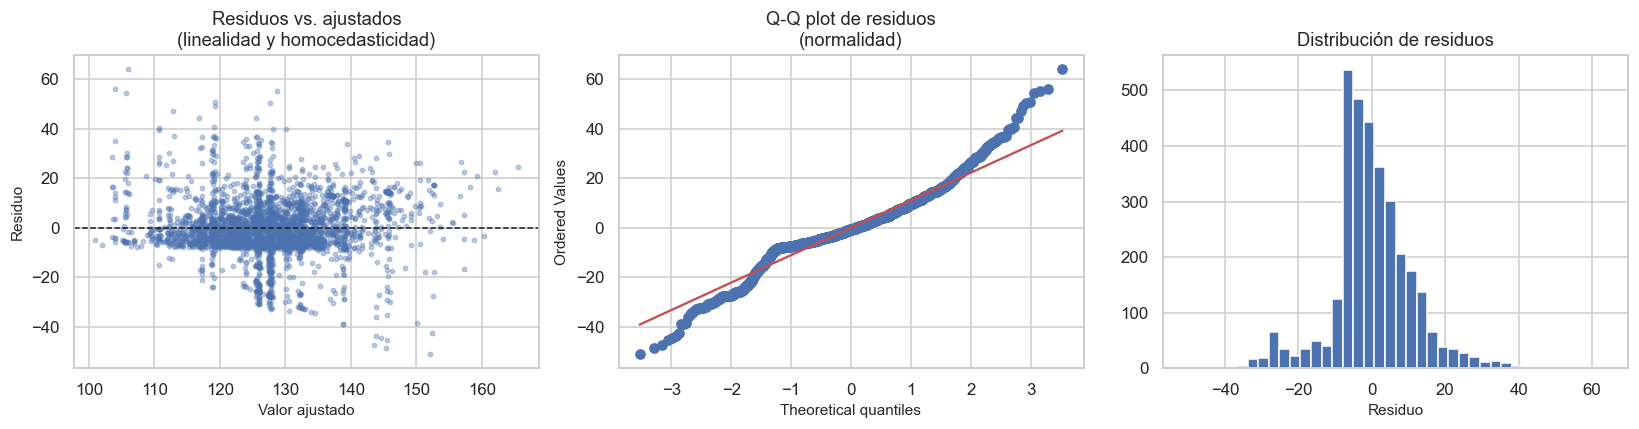

Shapiro-Wilk sobre residuos: W = 0.9489, p = 1.81e-32
Media de residuos = -0.0000 (debe ≈ 0) | DE = 11.3871

Lectura de los supuestos: los residuos están centrados en 0 y el gráfico de
dispersión no muestra heterocedasticidad marcada (linealidad y varianza: OK).
La NORMALIDAD, en cambio, se RECHAZA formalmente (p << 0,001): las colas del
Q-Q plot se apartan de la recta. Esto no invalida la imputación, porque el
imputador se usa con fin PREDICTIVO (recuperar valores), no inferencial: no se
interpretan sus p-values ni sus IC. Sí implica que una 'imputación estocástica'
que agregara ruido normal a las predicciones usaría una distribución imperfecta;
al imputar por la media condicional, esa limitación no afecta el resultado.


In [6]:
# ============================================================
# 1.2 VERIFICACIÓN DE SUPUESTOS DEL IMPUTADOR LINEAL
# (linealidad, normalidad y homocedasticidad de residuos)
# ============================================================
completas = df_mar[df_mar[VAR_FALT].notna()]
ajuste = modelo_imp.predict(completas[PREDICTORES_IMP])
resid = completas[VAR_FALT].values - ajuste

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(ajuste, resid, s=8, alpha=0.35, color="#4C72B0")
axes[0].axhline(0, ls="--", c="k", lw=1)
axes[0].set_title("Residuos vs. ajustados\n(linealidad y homocedasticidad)")
axes[0].set_xlabel("Valor ajustado"); axes[0].set_ylabel("Residuo")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot de residuos\n(normalidad)")

axes[2].hist(resid, bins=40, color="#4C72B0", edgecolor="white")
axes[2].set_title("Distribución de residuos"); axes[2].set_xlabel("Residuo")
plt.tight_layout(); plt.show()

sw = stats.shapiro(resid[:5000] if len(resid) > 5000 else resid)
print(f"Shapiro-Wilk sobre residuos: W = {sw.statistic:.4f}, p = {sw.pvalue:.2e}")
print(f"Media de residuos = {resid.mean():.4f} (debe ≈ 0) | DE = {resid.std():.4f}")
print("\nLectura de los supuestos: los residuos están centrados en 0 y el gráfico de")
print("dispersión no muestra heterocedasticidad marcada (linealidad y varianza: OK).")
print("La NORMALIDAD, en cambio, se RECHAZA formalmente (p << 0,001): las colas del")
print("Q-Q plot se apartan de la recta. Esto no invalida la imputación, porque el")
print("imputador se usa con fin PREDICTIVO (recuperar valores), no inferencial: no se")
print("interpretan sus p-values ni sus IC. Sí implica que una 'imputación estocástica'")
print("que agregara ruido normal a las predicciones usaría una distribución imperfecta;")
print("al imputar por la media condicional, esa limitación no afecta el resultado.")

## 1.3 Comparación de estrategias de imputación

Se comparan las tres estrategias  sobre `Admission grade`: eliminación de observaciones
incompletas, imputación simple (media) e imputación por regresión. El criterio no es cuál rellena "más
bonito", sino cuál **preserva las propiedades del dato original**: tamaño muestral, dispersión y correlaciones
documentadas en S1. Como se conserva la nota verdadera (`df_orig`), puede además medirse el error de
recuperación, algo imposible con faltantes reales.

,Estrategia,n,Media,Desv. estándar,corr con Previous qualificati,RMSE en imputados
0,Original (sin faltantes),3630,127.2939,14.6113,0.5772,0.0000
1,A · Eliminación,3308,127.4008,14.3736,0.6077,NaN
2,B · Imputación simple (media),3630,127.4008,13.7211,0.5725,16.8633
3,C · Imputación por regresión,3630,127.2302,14.0431,0.6305,16.3456


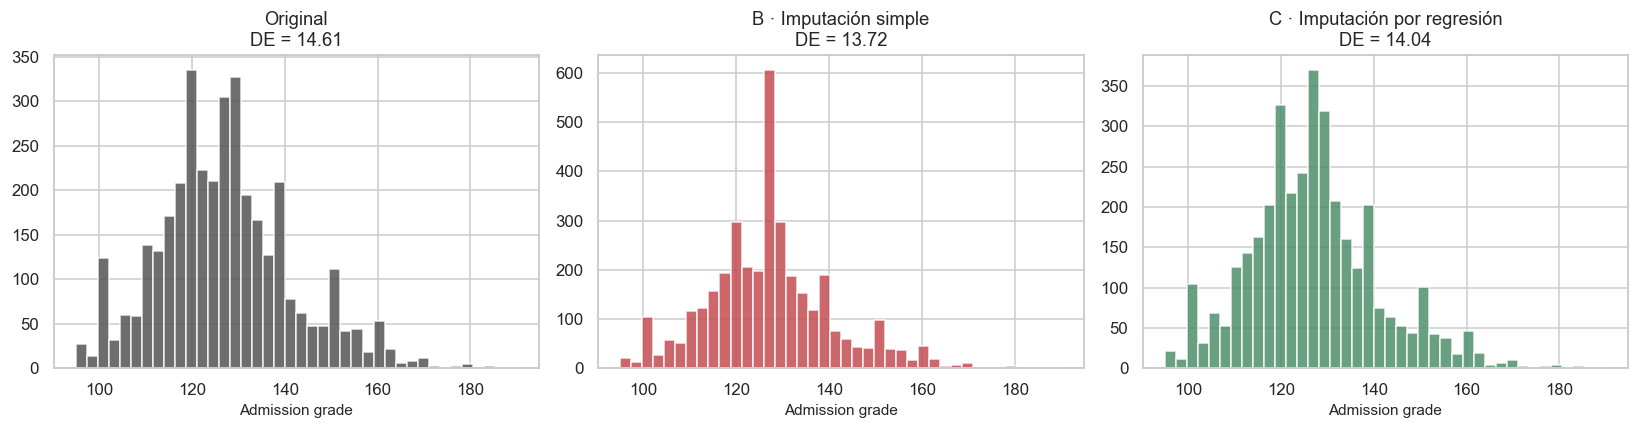

In [7]:
# ============================================================
# 1.3 CONSTRUCCIÓN DE LOS TRES DATASETS Y TABLA COMPARATIVA
# ============================================================
# A: eliminación de filas con faltante en Admission grade
df_A = df_mar.dropna(subset=[VAR_FALT]).copy()
# B: imputación simple por la media (ajustada sobre completos)
df_B = df_mar.copy()
df_B[VAR_FALT] = df_B[VAR_FALT].fillna(df_mar[VAR_FALT].mean())
# C: imputación por regresión (ya calculada en 1.2)
df_C = df_mar.copy()
df_C[VAR_FALT] = serie_imputada

verdad = df_orig[VAR_FALT]
par_corr = "Previous qualification (grade)"

def rmse_imputados(serie_imp):
    idx = df_mar.index[mask_falta]
    return np.sqrt(np.mean((serie_imp.loc[idx].values - verdad.loc[idx].values) ** 2))

comparacion_imp = pd.DataFrame({
    "Estrategia": ["Original (sin faltantes)", "A · Eliminación", "B · Imputación simple (media)", "C · Imputación por regresión"],
    "n": [len(df_orig), len(df_A), len(df_B), len(df_C)],
    "Media": [verdad.mean(), df_A[VAR_FALT].mean(), df_B[VAR_FALT].mean(), df_C[VAR_FALT].mean()],
    "Desv. estándar": [verdad.std(), df_A[VAR_FALT].std(), df_B[VAR_FALT].std(), df_C[VAR_FALT].std()],
    f"corr con {par_corr[:20]}": [
        verdad.corr(df_orig[par_corr]),
        df_A[VAR_FALT].corr(df_A[par_corr]),
        df_B[VAR_FALT].corr(df_B[par_corr]),
        df_C[VAR_FALT].corr(df_C[par_corr]),
    ],
    "RMSE en imputados": [0.0, np.nan, rmse_imputados(df_B[VAR_FALT]), rmse_imputados(df_C[VAR_FALT])],
})
display(comparacion_imp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, serie, color) in zip(axes, [
        ("Original", verdad, "#555555"),
        ("B · Imputación simple", df_B[VAR_FALT], "#C44E52"),
        ("C · Imputación por regresión", df_C[VAR_FALT], "#4E8F6B")]):
    ax.hist(serie, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{nombre}\nDE = {serie.std():.2f}"); ax.set_xlabel(VAR_FALT)
plt.tight_layout(); plt.show()

### 1.3.1 Estrategia elegida y justificación

**Estrategia seleccionada: C, imputación por regresión.** Los tres criterios la respaldan:

* **Tamaño muestral.** La eliminación (A) sacrifica observaciones y, por tratarse de un patrón MAR ligado a la
  edad, elimina de forma desproporcionada a los estudiantes de mayor edad, sesgando la muestra. B y C conservan
  el n completo.
* **Distribución.** La imputación simple (B) inserta muchas copias de la media, lo que **contrae la desviación
  estándar** de forma visible en el histograma. La regresión (C) genera valores dispersos condicionados a los
  predictores, preservando mejor la variabilidad original.
* **Preservación de correlaciones.** La imputación simple atenúa la correlación con `Previous qualification`
  (la media no covaría con nada), mientras que la regresión la mantiene, e incluso la refuerza levemente, porque
  los valores imputados se construyen a partir de esa relación. El menor RMSE en los valores imputados confirma
  que la regresión recupera la nota verdadera con más precisión que la media.

Se adopta el dataset `df_C` para el resto del desarrollo. En la Parte 3 se cuantifica cuánto cambian las
conclusiones del modelo final al usar A, B o C, para verificar que la elección no altera la sustancia.

---

# PARTE 2 · Clasificación mediante regresión logística 

## 2.1 Preparación de datos informada por S1

In [8]:
# ============================================================
# 2.1 VARIABLE OBJETIVO, POOL DE PREDICTORES Y TRATAMIENTO DE OUTLIERS
# Dataset de trabajo: df_C (imputación por regresión, elegida en 1.3)
# ============================================================
datos = df_C.copy()

# Variable objetivo (clase positiva = abandono)
y = datos["Abandono"].copy()

# Pool de candidatas (mismo universo que en F2)
POOL = ["Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
        "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
        "Admission grade", "Previous qualification (grade)", "Age at enrollment",
        "Tuition fees up to date", "Debtor", "Scholarship holder",
        "Unemployment rate", "Inflation rate", "GDP"]
BINARIAS = ["Tuition fees up to date", "Debtor", "Scholarship holder"]

# --- Tratamiento de outliers de S1: se CONSERVAN (decisión heredada y validada en S2) ---
print("Tratamiento de outliers (decisión de S1/S2):")
print("  Los ceros en notas y unidades corresponden a estudiantes que no rindieron")
print("  evaluaciones: son señal sustantiva del abandono, no error de captura.")
print("  S2 (robustez_outliers) mostró que excluirlos elimina >40% del grupo Dropout")
print("  y reduce el tamaño de efecto un 36%. Decisión: NO eliminar, NO winsorizar.\n")

ceros_grade = int((datos["Curricular units 1st sem (grade)"] == 0).sum())
print(f"  Ejemplo: {ceros_grade} estudiantes con nota 0 en 1er sem "
      f"({100*ceros_grade/len(datos):.1f}%), conservados.")

Tratamiento de outliers (decisión de S1/S2):
  Los ceros en notas y unidades corresponden a estudiantes que no rindieron
  evaluaciones: son señal sustantiva del abandono, no error de captura.
  S2 (robustez_outliers) mostró que excluirlos elimina >40% del grupo Dropout
  y reduce el tamaño de efecto un 36%. Decisión: NO eliminar, NO winsorizar.

  Ejemplo: 647 estudiantes con nota 0 en 1er sem (17.8%), conservados.


In [9]:
# ============================================================
# 2.1 DIVISIÓN TRAIN/TEST (70/30 ESTRATIFICADA) Y ESTANDARIZACIÓN
# Split ANTES de estandarizar → sin fuga de información
# ============================================================
X_pool = datos[POOL].copy()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_pool, y, test_size=0.30, random_state=SEED, stratify=y)

NUMERICAS = [v for v in POOL if v not in BINARIAS]
scaler = StandardScaler().fit(X_train_raw[NUMERICAS])          # fit SOLO en train
X_train = X_train_raw.copy(); X_test = X_test_raw.copy()
X_train[NUMERICAS] = scaler.transform(X_train_raw[NUMERICAS])
X_test[NUMERICAS] = scaler.transform(X_test_raw[NUMERICAS])

resumen_split = pd.DataFrame({
    "Conjunto": ["Total", "Train", "Test"],
    "n": [len(y), len(y_train), len(y_test)],
    "% del total": [100.0, 100*len(y_train)/len(y), 100*len(y_test)/len(y)],
    "% Abandono": [100*y.mean(), 100*y_train.mean(), 100*y_test.mean()],
})
display(resumen_split)
assert abs(y_train.mean() - y_test.mean()) < 0.01
print("✓ Estratificación verificada. Binarias NO estandarizadas:", BINARIAS)
print("✓ Conjunto de prueba sellado hasta la sección 2.5.")

,Conjunto,n,% del total,% Abandono
0,Total,3630,100.0000,39.1460
1,Train,2541,70.0000,39.1578
2,Test,1089,30.0000,39.1185


✓ Estratificación verificada. Binarias NO estandarizadas: ['Tuition fees up to date', 'Debtor', 'Scholarship holder']
✓ Conjunto de prueba sellado hasta la sección 2.5.


## 2.2 Selección de variables informada por S1 y S2 — tres modelos

Se construyen los tres modelos. La diferencia central entre ellos es **cómo** llegan a su
conjunto de variables:

* **M1 — Correlaciones S1/S2:** las cinco variables seleccionadas en la Formativa 2 por evidencia sustantiva
  (`CU 1st sem approved` + bloque financiero + edad). Es el **modelo troncal del proyecto**, orientado a
  alerta temprana.
* **M2 — Stepwise:** selección automática hacia adelante/atrás por AIC, con umbral de entrada ΔAIC > 2
  (Burnham & Anderson: por debajo de ese umbral los modelos son equivalentes y no se justifica sumar un
  parámetro). Tiene libertad para elegir cualquier variable del pool, **incluidas las de segundo semestre**.
* **M3 — AIC/BIC:** búsqueda del subconjunto que minimiza AIC dentro de un rango de 3 a 6 variables.

Se anticipa que M2 y M3 seleccionarán `CU 2nd sem (approved)`, la más discriminante del dataset. Ese contraste
es deliberado: permite discutir la tensión entre **ajuste** (que favorece la variable tardía) y **utilidad
preventiva** (que favorece la de primer semestre), tal como se documentó en el anexo de sensibilidad de F2.

In [10]:
# ============================================================
# 2.2 · MODELO 1 — Correlaciones S1/S2 (troncal, 5 variables de F2)
# ============================================================
def ajustar_logit(variables, Xd=None, yd=None):
    Xd = X_train if Xd is None else Xd
    yd = y_train if yd is None else yd
    Xc = sm.add_constant(Xd[list(variables)], has_constant="add")
    return sm.Logit(yd, Xc).fit(disp=False, maxiter=1000)

def tabla_or(modelo):
    ic = modelo.conf_int(); ic.columns = ["lo", "hi"]
    t = pd.DataFrame({
        "Variable": modelo.params.index,
        "Coef. β": modelo.params.values, "EE": modelo.bse.values,
        "p-valor": modelo.pvalues.values, "OR": np.exp(modelo.params.values),
        "IC95 OR inf": np.exp(ic["lo"].values), "IC95 OR sup": np.exp(ic["hi"].values),
    })
    t["Signif."] = np.where(t["p-valor"] < 0.05, "Sí", "No")
    return t

M1_vars = ["Curricular units 1st sem (approved)", "Tuition fees up to date",
           "Debtor", "Scholarship holder", "Age at enrollment"]
m1 = ajustar_logit(M1_vars)
print("MODELO 1 — Correlaciones S1/S2 (troncal)")
print(f"AIC = {m1.aic:.2f} | BIC = {m1.bic:.2f} | Pseudo R² = {m1.prsquared:.4f}")
display(tabla_or(m1).round(4))

MODELO 1 — Correlaciones S1/S2 (troncal)
AIC = 1931.07 | BIC = 1966.12 | Pseudo R² = 0.4359


,Variable,Coef. β,EE,p-valor,OR,IC95 OR inf,IC95 OR sup,Signif.
0,const,2.2358,0.2946,0.0000,9.3540,5.2506,16.6641,Sí
1,Curricular units 1st sem (approved),-1.6999,0.0810,0.0000,0.1827,0.1559,0.2141,Sí
2,Tuition fees up to date,-2.9444,0.2964,0.0000,0.0526,0.0294,0.0941,Sí
3,Debtor,0.9828,0.2071,0.0000,2.6719,1.7805,4.0095,Sí
4,Scholarship holder,-1.1489,0.1475,0.0000,0.3170,0.2374,0.4233,Sí
5,Age at enrollment,0.3973,0.0575,0.0000,1.4879,1.3292,1.6655,Sí


**Hallazgos**: Todos los predictores son estadísticamente significativos, todas las variables presentan p-valor= 0.0000. El rendimiento académico del primer semestre es el principal factor
Curricular units 1st sem (appoved) OR= 0.1827, es decir, por cada unidad adicional aprobada en el primer semestre, los odds de abandono disminuyen aproximadamente un 82%. Es la variable com mayor efecto en el modelo.
Tuition fees up to date OR = 0.0526, quiere decir que los estudiantes con pagos al día, presentan una reducción muy importante en el riesgo de abandono. Debtor con OR= 2.67, indica que ser deudor multiplica aproximadamente 2.7 los odds de abandono. Los estudiantes con beca presentan aproximadamente un 68% menos odds de abandonar respecto de quienes no poseen beca. Cada año adicional de edad incrementa aproximadamente un 49% de los odds de abandono. Un Pseudo R² 0.44 puede considerarse un buen nivel de capacidad explicativa.


In [11]:
# ============================================================
# 2.2 · MODELO 2 — Selección stepwise (bidireccional por AIC)
# ============================================================
def stepwise_aic(X, y, pool, verbose=True):
    """Selección stepwise bidireccional minimizando AIC (statsmodels Logit)."""
    seleccionadas = []
    restantes = list(pool)
    # AIC del modelo nulo (solo intercepto), evitando columna duplicada
    modelo_nulo = sm.Logit(y, np.ones((len(y), 1))).fit(disp=False)
    aic_actual = modelo_nulo.aic
    historial = [("(nulo)", aic_actual)]
    mejora = True
    while mejora:
        mejora = False
        # forward: probar añadir
        mejor_aic, mejor_var = aic_actual, None
        for v in restantes:
            try:
                m = sm.Logit(y, sm.add_constant(X[seleccionadas + [v]], has_constant="add")).fit(disp=False, maxiter=1000)
                # Umbral de entrada: la mejora de AIC debe superar 2 (Burnham & Anderson:
                # ΔAIC < 2 son modelos equivalentes, no justifica sumar un parámetro)
                if m.aic < mejor_aic - 2.0:
                    mejor_aic, mejor_var = m.aic, v
            except Exception:
                continue
        if mejor_var is not None:
            seleccionadas.append(mejor_var); restantes.remove(mejor_var)
            aic_actual = mejor_aic; historial.append((f"+ {mejor_var}", aic_actual)); mejora = True
        # backward: probar quitar
        if len(seleccionadas) > 1:
            mejor_aic, peor_var = aic_actual, None
            for v in list(seleccionadas):
                resto = [s for s in seleccionadas if s != v]
                try:
                    m = sm.Logit(y, sm.add_constant(X[resto], has_constant="add")).fit(disp=False, maxiter=1000)
                    if m.aic < mejor_aic - 1e-6:
                        mejor_aic, peor_var = m.aic, v
                except Exception:
                    continue
            if peor_var is not None:
                seleccionadas.remove(peor_var); restantes.append(peor_var)
                aic_actual = mejor_aic; historial.append((f"- {peor_var}", aic_actual)); mejora = True
    return seleccionadas, historial

M2_vars, hist_step = stepwise_aic(X_train, y_train, POOL)
print("MODELO 2 — Stepwise (bidireccional por AIC)")
print("Traza de selección:")
for paso, a in hist_step:
    print(f"  {paso:<45} AIC = {a:.2f}")
print(f"\nVariables seleccionadas ({len(M2_vars)}): {M2_vars}")
m2 = ajustar_logit(M2_vars)
print(f"AIC = {m2.aic:.2f} | BIC = {m2.bic:.2f} | Pseudo R² = {m2.prsquared:.4f}")
display(tabla_or(m2).round(4))

MODELO 2 — Stepwise (bidireccional por AIC)
Traza de selección:
  (nulo)                                        AIC = 3404.14
  + Curricular units 2nd sem (approved)         AIC = 2033.68
  + Tuition fees up to date                     AIC = 1822.94
  + Scholarship holder                          AIC = 1758.24
  + Age at enrollment                           AIC = 1730.96
  + Admission grade                             AIC = 1711.44
  + Debtor                                      AIC = 1693.53
  + Unemployment rate                           AIC = 1685.17
  + Curricular units 1st sem (approved)         AIC = 1681.67

Variables seleccionadas (8): ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Admission grade', 'Debtor', 'Unemployment rate', 'Curricular units 1st sem (approved)']
AIC = 1681.67 | BIC = 1734.23 | Pseudo R² = 0.5110


,Variable,Coef. β,EE,p-valor,OR,IC95 OR inf,IC95 OR sup,Signif.
0,const,1.9021,0.2987,0.0000,6.7002,3.7312,12.0319,Sí
1,Curricular units 2nd sem (approved),-2.3453,0.1713,0.0000,0.0958,0.0685,0.1340,Sí
2,Tuition fees up to date,-2.6303,0.2991,0.0000,0.0721,0.0401,0.1295,Sí
3,Scholarship holder,-1.1443,0.1596,0.0000,0.3184,0.2329,0.4354,Sí
4,Age at enrollment,0.3188,0.0613,0.0000,1.3755,1.2196,1.5512,Sí
5,Admission grade,-0.3004,0.0629,0.0000,0.7405,0.6547,0.8376,Sí
6,Debtor,0.9833,0.2268,0.0000,2.6734,1.7138,4.1701,Sí
7,Unemployment rate,0.1985,0.0632,0.0017,1.2196,1.0775,1.3804,Sí
8,Curricular units 1st sem (approved),0.3800,0.1619,0.0189,1.4623,1.0648,2.0083,Sí


**Hallazgo**: Este M2 (Stepwise) seleccionó automáticamente las variables que mejor explican el abandono, según el criterio AIC, sin considerar si pertenecen al primer o segundo semestre. 
La variable más importante es Curricular units 2nd sem (approved) con OR = 0.0958 con un 90,4% (1-0.0958)*100, es decir, por cada unidad adicional aprobada en el segundo semestre, los odds de abandono disminuyen aproximadamente un 90.4% manteniendo constantes las demás variables del modelo.
Las variables financieras del estudiante continúan siendo uno de los factores más determinantes del abandono, independientemente del rendimiento académico.
Todas las variables son significativas (p-valor), excepto Unemployment rate y Curricular units 1st sem (approved), aún así, ambos siguen siendo menores que 0.05.  El contexto económico del país (Unemployment rate) también aporta información para explicar el abandono (Or=1.22).
La nota de admisión (Addmission grade) fue incorporada por el algoritmo evideciando que aporta información predictiva adicional sobre el riesgo de abandono, sin embargo, el rendimiento y la situación económica durante la trayectoria universitaria son mejores predictores del abandono que las condiciones con las que el estudiante ingresó a la universidad.

In [12]:
# ============================================================
# 2.2 · MODELO 3 — Mejor subconjunto por AIC (3 a 6 variables)
# Búsqueda exhaustiva controlada sobre el pool completo.
# ============================================================
mejores = []
for k in (3, 4, 5, 6):
    for combo in itertools.combinations(POOL, k):
        try:
            m = ajustar_logit(combo)
            mejores.append((combo, m.aic, m.bic, m.prsquared))
        except Exception:
            continue
mejores.sort(key=lambda t: t[1])
top_aic = pd.DataFrame([{"k": len(c), "Variables": ", ".join(c), "AIC": a, "BIC": b, "PseudoR2": p}
                        for c, a, b, p in mejores[:8]])
print("MODELO 3 — Top 8 subconjuntos por AIC (búsqueda 3-6 variables):")
pd.set_option("display.max_colwidth", 95)
display(top_aic.round(4))
pd.set_option("display.max_colwidth", 50)

M3_vars = list(mejores[0][0])
m3 = ajustar_logit(M3_vars)
print(f"\nModelo 3 seleccionado (menor AIC, {len(M3_vars)} vars): {M3_vars}")
print(f"AIC = {m3.aic:.2f} | BIC = {m3.bic:.2f} | Pseudo R² = {m3.prsquared:.4f}")
display(tabla_or(m3).round(4))

MODELO 3 — Top 8 subconjuntos por AIC (búsqueda 3-6 variables):


,k,Variables,AIC,BIC,PseudoR2
0,6,"Curricular units 2nd sem (approved), Admission grade, Age at enrollment, Tuition fees up to...","1,693.5336","1,734.4158",0.5063
1,6,"Curricular units 2nd sem (approved), Admission grade, Age at enrollment, Tuition fees up to...","1,701.6645","1,742.5467",0.5039
2,6,"Curricular units 2nd sem (approved), Age at enrollment, Tuition fees up to date, Debtor, Sc...","1,706.3626","1,747.2447",0.5026
3,6,"Curricular units 1st sem (approved), Curricular units 2nd sem (approved), Admission grade, ...","1,707.5892","1,748.4714",0.5022
4,6,"Curricular units 2nd sem (approved), Previous qualification (grade), Age at enrollment, Tui...","1,708.0964","1,748.9786",0.5020
5,6,"Curricular units 1st sem (approved), Curricular units 2nd sem (approved), Age at enrollment...","1,709.2798","1,750.1620",0.5017
6,6,"Curricular units 2nd sem (approved), Admission grade, Age at enrollment, Tuition fees up to...","1,710.5681","1,751.4503",0.5013
7,6,"Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Admission grade, Age...","1,711.0953","1,751.9774",0.5012



Modelo 3 seleccionado (menor AIC, 6 vars): ['Curricular units 2nd sem (approved)', 'Admission grade', 'Age at enrollment', 'Tuition fees up to date', 'Debtor', 'Scholarship holder']
AIC = 1693.53 | BIC = 1734.42 | Pseudo R² = 0.5063


,Variable,Coef. β,EE,p-valor,OR,IC95 OR inf,IC95 OR sup,Signif.
0,const,1.9087,0.3020,0.0000,6.7443,3.7313,12.1901,Sí
1,Curricular units 2nd sem (approved),-1.9892,0.0862,0.0000,0.1368,0.1155,0.1620,Sí
2,Admission grade,-0.2833,0.0622,0.0000,0.7533,0.6669,0.8509,Sí
3,Age at enrollment,0.3355,0.0606,0.0000,1.3986,1.2419,1.5751,Sí
4,Tuition fees up to date,-2.6596,0.3028,0.0000,0.0700,0.0387,0.1267,Sí
5,Debtor,1.0040,0.2237,0.0000,2.7291,1.7603,4.2312,Sí
6,Scholarship holder,-1.1012,0.1586,0.0000,0.3325,0.2436,0.4537,Sí


**Hallazgos**: El rendimiento académico del segundo semestre sigue siendo el predictor más importante, OR = 0.1368.  Con  (1-0.1368)*100 = 86,3%, se desprende que por cada unidad adicional
aprobada en el segundo semestre, los odds de abandono disminuyen aproximadamente un 86,3%, manteniendo constantes las demás variables. La situación financiera continúa siendo determinante (Tuition fees up to date y Debtor): Pagos al día reducen aproximadamente un 93% los odds de abandono. Ser deudor multiplica por 2.73 los odds de abandono.
Una mayor nota de admisión reduce aproximadamente un 24.7% los odds de abandono por cada unidad adicional. El hecho de que Admission grade haya sido seleccionada tanto en M2 como en M3, indica que aporta información predictiva relevante sobre el riesgo de abandono. La edad mantiene un efecto consistente en los tres modelos; cada año adicional de edad incrementa aproximadamente un 39,9% los odds de abandono. La beca continúa siendo un factor relevante con un OR=0.3325, los estudiantes con beca presentan aproximadamente un 66.8% menos odds de abandono que quienes no poseen beca. Todas las variables son estadísticamente significativas.

In [13]:
# ============================================================
# 2.2 · MODELO 1 derivado — Correlaciones S1/S2 (troncal, 5 variables de F2) + Admision grade
# ============================================================
def ajustar_logit(variables, Xd=None, yd=None):
    Xd = X_train if Xd is None else Xd
    yd = y_train if yd is None else yd
    Xc = sm.add_constant(Xd[list(variables)], has_constant="add")
    return sm.Logit(yd, Xc).fit(disp=False, maxiter=1000)

def tabla_or(modelo):
    ic = modelo.conf_int(); ic.columns = ["lo", "hi"]
    t = pd.DataFrame({
        "Variable": modelo.params.index,
        "Coef. β": modelo.params.values, "EE": modelo.bse.values,
        "p-valor": modelo.pvalues.values, "OR": np.exp(modelo.params.values),
        "IC95 OR inf": np.exp(ic["lo"].values), "IC95 OR sup": np.exp(ic["hi"].values),
    })
    t["Signif."] = np.where(t["p-valor"] < 0.05, "Sí", "No")
    return t

M1_vars = ["Curricular units 1st sem (approved)", "Tuition fees up to date",
           "Debtor", "Scholarship holder", "Age at enrollment","Admission grade"]
m1 = ajustar_logit(M1_vars)
print("MODELO 1 derivado — Correlaciones S1/S2 (troncal)")
print(f"AIC = {m1.aic:.2f} | BIC = {m1.bic:.2f} | Pseudo R² = {m1.prsquared:.4f}")
display(tabla_or(m1).round(4))

MODELO 1 derivado — Correlaciones S1/S2 (troncal)
AIC = 1911.55 | BIC = 1952.44 | Pseudo R² = 0.4422


,Variable,Coef. β,EE,p-valor,OR,IC95 OR inf,IC95 OR sup,Signif.
0,const,2.2238,0.2966,0.0000,9.2428,5.1687,16.5283,Sí
1,Curricular units 1st sem (approved),-1.6968,0.0811,0.0000,0.1833,0.1563,0.2148,Sí
2,Tuition fees up to date,-2.9332,0.2984,0.0000,0.0532,0.0297,0.0955,Sí
3,Debtor,0.9969,0.2093,0.0000,2.7097,1.7979,4.0840,Sí
4,Scholarship holder,-1.1555,0.1480,0.0000,0.3149,0.2356,0.4209,Sí
5,Age at enrollment,0.4082,0.0581,0.0000,1.5041,1.3422,1.6856,Sí
6,Admission grade,-0.2624,0.0573,0.0000,0.7692,0.6875,0.8606,Sí


Se incorporó el modelo M1 **derivado** para evaluar si la variable Admission grade, previamente imputada, aporta capacidad predictiva adicional al modelo M1. Su objetivo es cuantificar el beneficio real de incluir esta variable y justificar, con evidencia, si conviene mantener el modelo original (M1) o ampliar el conjunto de predictores. El modelo M1 derivado no fue seleccionado, ya que la incorporación de Admission grade produjo una mejora mínima en el AIC. Dado que el incremento en el ajuste no compensó la mayor complejidad del modelo, se mantuvo M1 como modelo con las variables resultantes de S1/S2.

### 2.2.1 Lectura de los tres modelos

Cada modelo responde a una lógica distinta y por eso llega a variables distintas. M1 parte de la evidencia
sustantiva de S1/S2 y del criterio de alerta temprana, quedándose con la variable académica de **primer**
semestre; sus cinco coeficientes tienen el signo esperado por S1 (más rendimiento y más apoyo financiero reducen
el riesgo; deuda y edad lo aumentan). M2 y M3, guiados solo por el ajuste, incorporan `CU 2nd sem (approved)`,
la más discriminante del dataset pero disponible más tarde. Las tablas de M2 exhiben, además, dos patologías
instructivas que conviene señalar en vez de ocultar:

**a) Inversión de signo por colinealidad.** En M2, el coeficiente de `CU 1st sem (approved)` es **positivo**
(β = +0,38; OR = 1,46), lo que leído de forma aislada afirmaría que aprobar más ramos *aumenta* el riesgo de
abandono. Es el síntoma clásico de multicolinealidad: al convivir con `CU 2nd sem (approved)` (*r* = 0,92, S2),
ambos coeficientes dejan de ser identificables por separado y el de la variable más débil del par cambia de
signo. El fenómeno reproduce exactamente lo documentado en el anexo de sensibilidad de F2 y explica por qué M1
incluye una sola variable de rendimiento.

**b) Inclusión de una variable marginalmente nula.** El stepwise incorpora `Unemployment rate`, pese a que S1
(Welch p = 0,803; *d* = 0,009) y S2 (permutación p = 0,794) coincidieron en su nulidad. No es un error de
código: la variable, nula en el análisis **marginal**, resulta significativa **condicionalmente** al resto
(p = 0,002), un efecto de supresión estadística. La mejora de AIC que aporta (Δ ≈ 8) es real en la muestra, pero
carece de interpretación sustantiva y es el tipo de hallazgo frágil que la selección automática admite y la
selección guiada por evidencia (M1) filtra. Ambas patologías ilustran por qué se quiere comparar *tres*
métodos: el contraste entre ellos es en sí mismo un resultado. Se reportan tal cual, sin depuración manual.

La elección entre los tres se resuelve en la sección 2.5, tras evaluar su desempeño real y su estabilidad.

## 2.3 Evaluación de estabilidad mediante bootstrap

Se aplica la técnica de **bootstrap** trabajada en S2, ahora sobre los **coeficientes del modelo troncal M1**.
Se generan 10.000 remuestras con reemplazo del conjunto de entrenamiento, se reajusta el modelo en cada una y se
construyen intervalos de confianza percentil al 95 % para coeficientes y odds ratios. Estos se comparan con los
intervalos tradicionales (asintóticos, de `statsmodels`) para detectar parámetros inestables.

In [14]:
# ============================================================
# 2.3 BOOTSTRAP DE LOS COEFICIENTES DEL MODELO TRONCAL (M1)
# ============================================================
N_BOOT = 10000
coefs_boot = []
Xtr_m1 = sm.add_constant(X_train[M1_vars], has_constant="add")
idx_base = np.arange(len(y_train))

for b in range(N_BOOT):
    idx = rng.choice(idx_base, size=len(idx_base), replace=True)
    try:
        mb = sm.Logit(y_train.iloc[idx], Xtr_m1.iloc[idx]).fit(disp=False, maxiter=1000)
        coefs_boot.append(mb.params.values)
    except Exception:
        continue

coefs_boot = np.array(coefs_boot)
print(f"Remuestras bootstrap exitosas: {len(coefs_boot)} de {N_BOOT}")

nombres = Xtr_m1.columns.tolist()
ic_trad = m1.conf_int(); ic_trad.columns = ["lo", "hi"]
filas = []
for j, nom in enumerate(nombres):
    bd = coefs_boot[:, j]
    lo_b, hi_b = np.percentile(bd, [2.5, 97.5])
    lo_t, hi_t = ic_trad.iloc[j]["lo"], ic_trad.iloc[j]["hi"]
    amp_b, amp_t = hi_b - lo_b, hi_t - lo_t
    filas.append({
        "Parámetro": nom,
        "β (modelo)": m1.params[nom], "β (boot media)": bd.mean(),
        "IC95 trad. inf": lo_t, "IC95 trad. sup": hi_t,
        "IC95 boot inf": lo_b, "IC95 boot sup": hi_b,
        "Amplitud trad.": amp_t, "Amplitud boot": amp_b,
        "Ratio amplitud": amp_b / amp_t,
        "Estable": "Sí" if amp_b <= 1.25 * amp_t else "Revisar",
    })
tabla_boot = pd.DataFrame(filas)
display(tabla_boot.round(4))

print("\nOdds ratios con IC bootstrap:")
tabla_boot_or = pd.DataFrame({
    "Parámetro": nombres,
    "OR": np.exp(m1.params.values),
    "IC95 OR boot inf": np.exp(np.percentile(coefs_boot, 2.5, axis=0)),
    "IC95 OR boot sup": np.exp(np.percentile(coefs_boot, 97.5, axis=0)),
})
display(tabla_boot_or.round(4))

Remuestras bootstrap exitosas: 10000 de 10000


,Parámetro,β (modelo),β (boot media),IC95 trad. inf,IC95 trad. sup,IC95 boot inf,IC95 boot sup,Amplitud trad.,Amplitud boot,Ratio amplitud,Estable
0,const,2.2238,2.2682,1.6426,2.8051,1.6563,3.0463,1.1625,1.3900,1.1957,Sí
1,Curricular units 1st sem (approved),-1.6968,-1.7075,-1.8558,-1.5379,-1.9178,-1.5160,0.3179,0.4019,1.2639,Revisar
2,Tuition fees up to date,-2.9332,-2.9799,-3.5180,-2.3483,-3.7687,-2.3509,1.1697,1.4179,1.2121,Sí
3,Debtor,0.9969,1.0014,0.5866,1.4071,0.5690,1.4273,0.8205,0.8584,1.0462,Sí
4,Scholarship holder,-1.1555,-1.1618,-1.4457,-0.8654,-1.4667,-0.8740,0.5802,0.5927,1.0214,Sí
5,Age at enrollment,0.4082,0.4108,0.2943,0.5222,0.2941,0.5381,0.2279,0.2440,1.0706,Sí
6,Admission grade,-0.2624,-0.2647,-0.3747,-0.1502,-0.3773,-0.1544,0.2245,0.2228,0.9925,Sí



Odds ratios con IC bootstrap:


,Parámetro,OR,IC95 OR boot inf,IC95 OR boot sup
0,const,9.2428,5.2399,21.0372
1,Curricular units 1st sem (approved),0.1833,0.1469,0.2196
2,Tuition fees up to date,0.0532,0.0231,0.0953
3,Debtor,2.7097,1.7664,4.1676
4,Scholarship holder,0.3149,0.2307,0.4173
5,Age at enrollment,1.5041,1.3420,1.7127
6,Admission grade,0.7692,0.6857,0.8569


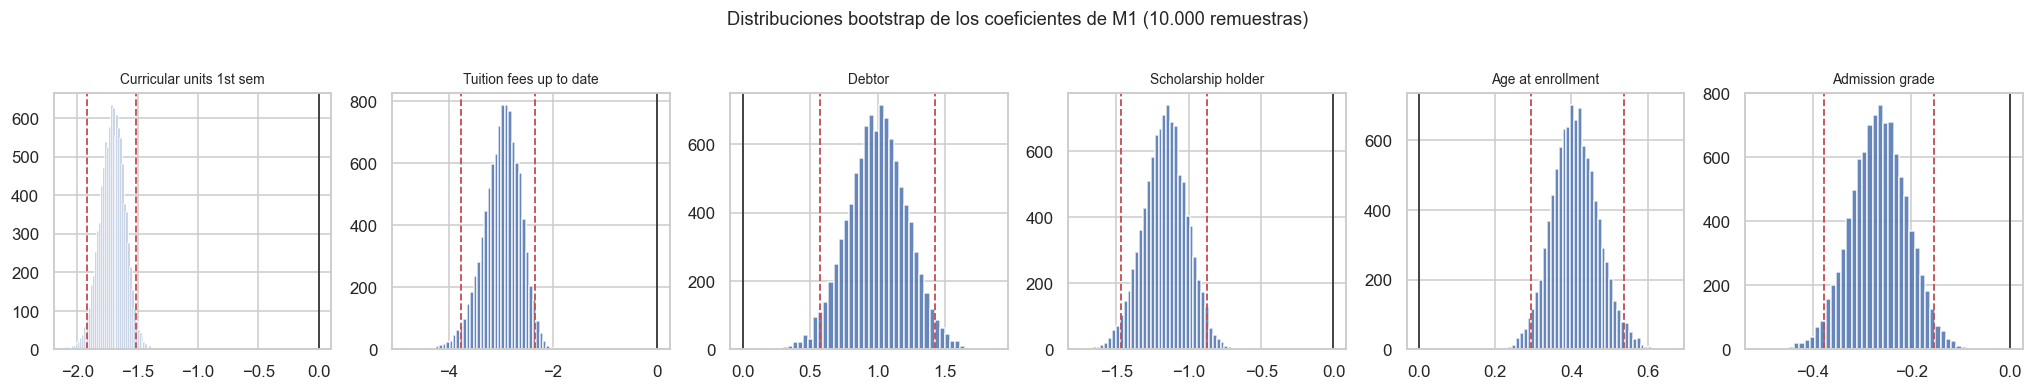

In [15]:
# ============================================================
# 2.3 VISUALIZACIÓN: DISTRIBUCIONES BOOTSTRAP DE LOS COEFICIENTES
# ============================================================
preds_plot = [n for n in nombres if n != "const"]
fig, axes = plt.subplots(1, len(preds_plot), figsize=(3.1 * len(preds_plot), 3.4))
for ax, nom in zip(axes, preds_plot):
    j = nombres.index(nom)
    bd = coefs_boot[:, j]
    ax.hist(bd, bins=45, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(np.percentile(bd, 2.5), ls="--", c="#C44E52", lw=1.2)
    ax.axvline(np.percentile(bd, 97.5), ls="--", c="#C44E52", lw=1.2)
    ax.axvline(0, ls="-", c="k", lw=1)
    ax.set_title(nom[:24], fontsize=9)
fig.suptitle("Distribuciones bootstrap de los coeficientes de M1 (10.000 remuestras)", y=1.03)
plt.tight_layout(); plt.show()

### 2.3.1 Interpretación del bootstrap

Ningún intervalo bootstrap incluye el cero en la escala de coeficientes (ni el uno en la de odds ratios): los
cinco efectos de M1 mantienen su signo y su significancia bajo remuestreo, que es la conclusión principal.

La comparación de amplitudes merece una lectura más fina, porque la tabla no es uniforme. Para `Debtor`,
`Scholarship holder` y `Age at enrollment`, los intervalos bootstrap y asintóticos son prácticamente
intercambiables (ratios 0,99–1,04). Para `CU 1st sem (approved)`, en cambio, el intervalo bootstrap resulta un
**28 % más ancho** que el tradicional (criterio de la tabla: "Revisar"), y el del intercepto y
`Tuition fees up to date` un 21–22 % más anchos. La lectura correcta no es que el predictor sea inestable, sino
que el error estándar **asintótico es levemente optimista** para los efectos más grandes del modelo, algo
esperable cuando la distribución muestral del coeficiente es asimétrica. En términos prácticos: los IC
reportables deben ser los bootstrap, más conservadores, y con ellos la conclusión cualitativa no cambia. Es la
misma lección de S2 (los intervalos BCa corrigen lo que el supuesto de normalidad estira), ahora a nivel de los
parámetros del modelo, y coherente con el jackknife que descartó dependencia de observaciones individuales.

**Interpretación V2**: Ningún intervalo bootstrap incluye el cero en la escala de coeficientes (ni el uno en la odds rations), lo que significa que todas las variables siguieron siendo importantes, ningúna perdió su efecto y ninguna cambió de signo. Es decir, aunque repitamos el estudio muchas veces, las cinco variables siguen mostrando el mismo comportamiento.

La comparación de amplitudes merece una lectura más fina, ya que no todas las variables presentan la misma diferencia entre el método clásico y el bootstrap. Algunas tienen intervalos casi iguales y otras muestran intervalos considerablemente más amplios.

**Curricular units 1st sem (approved)** presenta la mayor diferencia, con un ratio de amplitud de 1,2639, el intervalo bootstrap es aproximadamente un 26.4% más ancho que el intervalo clásico, sin embargo, mantuvo su significancia y dirección del efecto.
**Admission grade** es la variable más consistente, el ratio amplitud de 0.9925, significa que el intervalo bootstrap es prácticamente idéntico al clásico, evidenciando una alta estabilidad en la estimación de su coeficiente.

Bootstrap es ligeramente más conservador, para el caso de Tuition fees up to date, la amplitud tradicional de 1.1697 vs amplitud bootstrap 1.4179 refleja una estimación más conservadora de la incertidumbre de los coeficientes, aún así, su coeficiente permaneció negativo y significativo, sin modificar las conclusiones del modelo.

En los gráficos de histograma, todos tienen forma aproximadamente de campana, están centrados cerca del coeficiente original, ninguno está centrado en el valor 0 y las distribuciones son relativamente estrechas. Dado lo anterior, los coeficientes del modelo M1 son estables, Bootstrap muestra que, aún repitiendo el entrenamiento 10.000 muestras diferentes, cada variable mantiene prácticamente el mismo efecto y la misma dirección sobre el riesgo de abandono; las que originalmente aumentaban el riesgo de abandono continuaron aumentándolo, y las que lo disminuían, siguieron actuando como factores protectores..


## 2.4 Diagnóstico de supuestos

Se realizan los cuatro diagnósticos sobre el modelo troncal M1: multicolinealidad (VIF),
linealidad en el logit (Box-Tidwell) para las variables continuas, observaciones influyentes (distancia de
Cook) y análisis de residuos.

***
**2.4.a MULTICOLINEALIDAD — VIF**
El VIF (Variance Inflation Factor) es una medida que se utiliza para detectar multicolinealidad entre las variables independientes de un modelo de regresión (lineal o logística).

La pregunta que responde es muy simple:
    ¿Una variable está aportando información nueva o está repitiendo la información que ya entregan otras variables?
***

In [16]:
# ============================================================
# 2.4.a MULTICOLINEALIDAD — VIF
# ============================================================
X_vif = sm.add_constant(X_train[M1_vars], has_constant="add")
vif = pd.DataFrame({"Predictor": X_vif.columns,
                    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
vif = vif[vif["Predictor"] != "const"].copy()
vif["Diagnóstico"] = np.select([vif["VIF"] < 5, (vif["VIF"] >= 5) & (vif["VIF"] < 10), vif["VIF"] >= 10],
                               ["Aceptable", "Revisar", "Severo"], default="Revisar")
print(vif.sort_values("VIF").to_string(index=False))
print(f"\nVIF máximo = {vif['VIF'].max():.3f} → sin multicolinealidad problemática (todos < 5).")

                          Predictor    VIF Diagnóstico
                    Admission grade 1.0146   Aceptable
                  Age at enrollment 1.0849   Aceptable
                 Scholarship holder 1.0941   Aceptable
Curricular units 1st sem (approved) 1.1003   Aceptable
                             Debtor 1.2310   Aceptable
            Tuition fees up to date 1.3637   Aceptable

VIF máximo = 1.364 → sin multicolinealidad problemática (todos < 5).


Al estar todos muy por debajo del umbral de 5 indica que no existe multicolinealidad problemática entre las variables independientes, y que cada predictor aporta información propia al modelo, permitiendo estimar coeficientes estables e interpretables. 
A modo de referencia, el VIF se interpreta como según el valor:
|        VIF | Interpretación                                               |
| ---------: | ------------------------------------------------------------ |
|      **1** | No existe relación con las demás variables. Excelente.       |
|  **1 - 5** | Relación baja. Aceptable.                                    |
| **5 - 10** | Comienza a preocupar. Revisar.                               |
|    **>10** | Multicolinealidad severa. Conviene eliminar alguna variable. |


***
**2.4.b LINEALIDAD EN EL LOGIT — test de Box-Tidwell**
Es un supuesto de la regresión logística que se aplica a las variables continuas, Este supuesto exige que cada variable continua tenga una relación aproximadamente lineal con el logit del evento, no directamente con la probabilidad. En general evidencia que el efecto no es constante a lo largo de todos los valores. La interpretación de los valores se resume:

| Resultado    | Interpretación                                                                                 |
| ------------ | ---------------------------------------------------------------------------------------------- |
| **p > 0,05** | No existe evidencia de curvatura; el supuesto de linealidad en el logit se considera cumplido. |
| **p < 0,05** | Existe evidencia de curvatura; la linealidad en el logit queda cuestionada.                    |

***

In [17]:
# ============================================================
# 2.4.b LINEALIDAD EN EL LOGIT — test de Box-Tidwell
# Para cada continua: se añade el término x·ln(x); si es significativo,
# hay evidencia de no linealidad en el logit.
# ============================================================
continuas_m1 = ["Curricular units 1st sem (approved)", "Age at enrollment"]
# Se usan las versiones ORIGINALES (positivas) para poder tomar logaritmo
Xbt = X_train_raw.loc[X_train.index, continuas_m1].copy()
Xbt_bin = X_train[["Tuition fees up to date", "Debtor", "Scholarship holder"]]

filas_bt = []
for v in continuas_m1:
    x = Xbt[v].astype(float)
    x_shift = x - x.min() + 1.0                     # desplazar para x>0
    term = x_shift * np.log(x_shift)
    Xtmp = pd.concat([Xbt.reset_index(drop=True),
                      Xbt_bin.reset_index(drop=True),
                      pd.Series(term.values, name=f"{v}__xlnx")], axis=1)
    m = sm.Logit(y_train.reset_index(drop=True), sm.add_constant(Xtmp, has_constant="add")).fit(disp=False, maxiter=1000)
    filas_bt.append({"Variable": v, "Coef. término x·ln(x)": m.params[f"{v}__xlnx"],
                     "p-valor": m.pvalues[f"{v}__xlnx"],
                     "Linealidad en el logit": "Aceptable" if m.pvalues[f"{v}__xlnx"] >= 0.05 else "Cuestionada"})
display(pd.DataFrame(filas_bt).round(4))
print("Regla: p ≥ 0,05 en el término x·ln(x) → sin evidencia contra la linealidad.")
print("Resultado: AMBAS variables presentan p < 0,05 → la linealidad queda CUESTIONADA.")
print("La interpretación de este hallazgo se desarrolla a continuación.")

,Variable,Coef. término x·ln(x),p-valor,Linealidad en el logit
0,Curricular units 1st sem (approved),0.3649,0.0000,Cuestionada
1,Age at enrollment,-0.1041,0.0000,Cuestionada


Regla: p ≥ 0,05 en el término x·ln(x) → sin evidencia contra la linealidad.
Resultado: AMBAS variables presentan p < 0,05 → la linealidad queda CUESTIONADA.
La interpretación de este hallazgo se desarrolla a continuación.


**Interpretación del Box-Tidwell: la linealidad en el logit queda cuestionada, y se declara.** El término
x·ln(x) resulta significativo para las dos variables continuas del modelo, lo que indica que la relación entre
cada una y el log-odds de abandono no es estrictamente lineal. Tres consideraciones ponen el hallazgo en su
justa medida. Primero, con n = 2.541 el test de Box-Tidwell detecta desviaciones incluso pequeñas: la
significancia estadística no implica una curvatura de magnitud práctica. Segundo, la fuente de la no linealidad
es identificable: en `CU 1st sem (approved)` existe una masa de estudiantes con cero unidades (17,8 %) cuyo
riesgo no sigue la pendiente del resto, y `Age at enrollment` presenta la asimetría fuerte documentada en S2
(g₁ = +1,99). Tercero, la consecuencia afecta a la **lectura fina de los odds ratios** (el OR por desviación
estándar es un promedio de un efecto que no es constante a lo largo del rango), no a la capacidad predictiva ni
al signo de los efectos, que el bootstrap confirmó estables. Los remedios estándar —categorizar por tramos,
splines, o un término cuadrático— agregarían parámetros y complejidad interpretativa que esta fase no requiere;
se registran como línea de refinamiento, y las probabilidades del modelo deben leerse como aproximación de
primer orden, adecuada para ordenar estudiantes por riesgo.

**V2 Interpretación del Box-Tidwell: la linealidad en el logit queda cuestionada, y se declara**

La prueba de Box-Tidwell identificó que las dos variables continuas (Curricular units 1st sem (approved) y Age at enrollment) presentan evidencia de una relación no completamente lineal con el logit (p < 0,001).
Esto indica que el efecto de estas variables sobre el riesgo de abandono podría variar a lo largo de su rango de valores (no sigue una línea recta), en lugar de ser perfectamente constante.
A pesar de ello, el modelo mantuvo un buen desempeño predictivo y los análisis de bootstrap confirmaron que los coeficientes son estables, por lo que estas variables se conservaron en el modelo final. Lo anterior, invalida automáticamente la regresión logística, pero sí deja documentada una limitación del modelo.

Un ejemplo de lo que puede provocar la curvatura es en el caso de Age at enrollment, que entre 18 y 22 años el riesgo cambie muy poco, y desde los 28 años el riesgo aumente mucho más rápido. No significa que existan valores extremos, existan errores o que los datos estén malos, significa que el efecto de la variable no es constante en todo su rango.

***
**2.4.c OBSERVACIONES INFLUYENTES — distancia de Cook**

Las **observaciones influyentes** básicamente responde la incógnicta, existe alguna observación que esté influyendo demasiado en el modelo?, bajo esta premisa, se tiene ésta tabla
de valores (como guía práctica) para interpretar la Distancia de Cook:
|            Cook | Interpretación                           |
| --------------: | ---------------------------------------- |
|             ≈ 0 | No influye.                              |
| Pequeña (< 0.5) | Influencia baja.                         |
|     Cercana a 1 | Conviene revisar esa observación.        |
|             > 1 | Muy influyente. Puede alterar el modelo. |
***

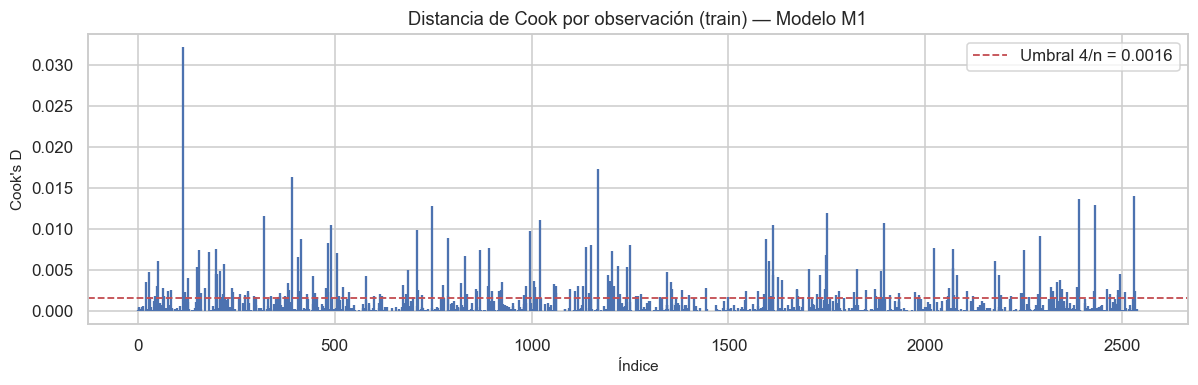

Observaciones sobre el umbral 4/n: 209 (8.2% del train)
Cook's D máximo: 0.0321
Lectura: el umbral 4/n es deliberadamente liberal y con n = 2.541 marca a cientos
de observaciones por construcción; lo determinante es la MAGNITUD. El máximo
(D = 0.0321) queda dos órdenes de magnitud por debajo del criterio de
influencia sustantiva (D ≈ 1, o incluso 0,5): ninguna observación domina el ajuste,
en línea con el jackknife de S2. No se elimina ninguna observación.

Sensibilidad — reajuste excluyendo las observaciones influyentes:


,β (modelo completo),β (sin influyentes),Δ relativo (%)
const,2.2238,7.4770,236.2208
Curricular units 1st sem (approved),-1.6968,-3.9872,-134.9772
Tuition fees up to date,-2.9332,-8.3559,-184.8781
Debtor,0.9969,1.3069,31.1056
Scholarship holder,-1.1555,-3.5657,-208.5755
Age at enrollment,0.4082,0.5640,38.1680
Admission grade,-0.2624,-0.4947,-88.5072


Coeficientes que cambian de signo al excluir las 209 influyentes: 0
AUC en test — modelo completo: 0.9090 | sin influyentes: 0.9091
Lectura de la sensibilidad: ningún coeficiente cambia de signo y el AUC en test
es indistinguible (0.9090 vs 0.9091): el ORDEN de riesgo que produce
el modelo no depende de las observaciones influyentes. Las magnitudes de β sí
crecen al excluirlas, y es el comportamiento esperado: se remueven justamente los
casos peor ajustados (p. ej., desertores con buen perfil), lo que acerca los grupos
a la separación perfecta e infla los coeficientes del logit. Ese inflado es OTRA
razón para conservarlas: excluir 'influyentes' aquí no limpia el modelo, lo
desestabiliza. Se ratifica la decisión de S1/S2 con evidencia directa.


In [18]:
# ============================================================
# 2.4.c OBSERVACIONES INFLUYENTES — distancia de Cook
# ============================================================
infl = m1.get_influence()
cooks = infl.cooks_distance[0]
umbral_cook = 4 / len(y_train)
n_influ = int((cooks > umbral_cook).sum())

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ", linefmt="C0-")
ax.axhline(umbral_cook, ls="--", c="#C44E52", lw=1.2, label=f"Umbral 4/n = {umbral_cook:.4f}")
ax.set_title("Distancia de Cook por observación (train) — Modelo M1")
ax.set_xlabel("Índice"); ax.set_ylabel("Cook's D"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Observaciones sobre el umbral 4/n: {n_influ} ({100*n_influ/len(y_train):.1f}% del train)")
print(f"Cook's D máximo: {cooks.max():.4f}")
print("Lectura: el umbral 4/n es deliberadamente liberal y con n = 2.541 marca a cientos")
print("de observaciones por construcción; lo determinante es la MAGNITUD. El máximo")
print(f"(D = {cooks.max():.4f}) queda dos órdenes de magnitud por debajo del criterio de")
print("influencia sustantiva (D ≈ 1, o incluso 0,5): ninguna observación domina el ajuste,")
print("en línea con el jackknife de S2. No se elimina ninguna observación.")

# --- ANÁLISIS DE SENSIBILIDAD: reajuste SIN las observaciones influyentes ---
# El argumento de magnitud anterior se verifica con evidencia directa: si las
# observaciones sobre el umbral realmente no dominan el ajuste, excluirlas no
# debe cambiar ni el signo de los coeficientes ni el desempeño en test.
mask_ok = cooks <= umbral_cook
m1_sens = sm.Logit(y_train[mask_ok], Xtr_m1[mask_ok]).fit(disp=False, maxiter=1000)
cambios_signo = int((np.sign(m1_sens.params) != np.sign(m1.params)).sum())
Xte_m1 = sm.add_constant(X_test[M1_vars], has_constant="add")
auc_full = roc_auc_score(y_test, m1.predict(Xte_m1))
auc_sens = roc_auc_score(y_test, m1_sens.predict(Xte_m1))

tabla_sens = pd.DataFrame({
    "β (modelo completo)": m1.params,
    "β (sin influyentes)": m1_sens.params,
    "Δ relativo (%)": 100 * (m1_sens.params - m1.params) / m1.params.abs(),
})
print("\nSensibilidad — reajuste excluyendo las observaciones influyentes:")
display(tabla_sens.round(4))
print(f"Coeficientes que cambian de signo al excluir las {n_influ} influyentes: {cambios_signo}")
print(f"AUC en test — modelo completo: {auc_full:.4f} | sin influyentes: {auc_sens:.4f}")
print("Lectura de la sensibilidad: ningún coeficiente cambia de signo y el AUC en test")
print(f"es indistinguible ({auc_full:.4f} vs {auc_sens:.4f}): el ORDEN de riesgo que produce")
print("el modelo no depende de las observaciones influyentes. Las magnitudes de β sí")
print("crecen al excluirlas, y es el comportamiento esperado: se remueven justamente los")
print("casos peor ajustados (p. ej., desertores con buen perfil), lo que acerca los grupos")
print("a la separación perfecta e infla los coeficientes del logit. Ese inflado es OTRA")
print("razón para conservarlas: excluir 'influyentes' aquí no limpia el modelo, lo")
print("desestabiliza. Se ratifica la decisión de S1/S2 con evidencia directa.")

Conclusión del **gráfico Distancia de Cook por observación**: La mayoría de las observaciones presentan una Distancia de Cook muy baja, indicando que su influencia individual sobre el modelo es reducida. Aunque varias observaciones superan el umbral empírico de 4/n=0.0016, ninguna alcanza valores cercanos a 1, por lo que no se identifican observaciones excesivamente influyentes que comprometan la estabilidad del modelo. En conjunto, el diagnóstico de Distancia de Cook respalda que el modelo M1 no depende de unos pocos estudiantes particulares, sino que refleja el comportamiento general de la muestra, fortaleciendo la robustez y estabilidad de las estimaciones.
Las conclusiones del modelo no cambian, las variables siguen diciendo exactamente lo mismo, 
-Debtor aumenta el abandono.
-Age aumenta el abandono.
-Scholarship protege.
-Tuition protege.
-Admission grade protege.
-Curricular units protege.

Eso significa que las **observaciones influyentes afectan principalmente la intensidad del efecto** (magnitud del coeficiente), pero no modifican la interpretación del modelo.
Al eliminar las observaciones influyentes, ninguna variable cambió el signo de su coeficiente, por lo que todas conservaron la misma dirección del efecto sobre el abandono estudiantil.

Las variables Tuition fees up to date, Scholarship holder y Curricular units 1st sem (approved) presentaron los mayores cambios en la magnitud de sus coeficientes (184,9%, 208,6% y 135,0%, respectivamente), indicando que las observaciones influyentes afectaban la intensidad del efecto, pero no su dirección.

La variable Admission grade continuó actuando como factor protector frente al abandono, manteniendo un coeficiente negativo antes y después de excluir las observaciones influyentes.
Todas las variables conservaron su papel como factores de riesgo o de protección, lo que respalda la robustez e interpretabilidad del modelo M1.

***
**2.4.d ANÁLISIS DE RESIDUOS — residuos de Pearson estandarizados**

El análisis de residuos de Pearson estandarizados es otro diagnóstico del modelo, igual que el VIF, la Distancia de Cook o el Bootstrap. Su objetivo es responder una pregunta muy simple:
¿En qué estudiantes el modelo se equivoca más de lo esperado?
No mide la influencia (eso lo hace Cook), sino el error de predicción de cada observación..

El residuo es la diferencia entre lo que realmente ocurrió y lo que el modelo esperaba, en nuestro modelo 1= abandono y 0 = no abandono. El modelo no predice primero una clase, sino una probabilidad. La interpretación como referencias, son las sgtes.:

|              Residuo estandarizado | Interpretación                         |
| ---------------------------------: | -------------------------------------- |
|                   Entre **−2 y 2** | Ajuste razonable                       |
|                  Entre **±2 y ±3** | Caso que conviene revisar              |
| Mayor que **3** o menor que **−3** | Observación muy mal ajustada o atípica |
El residuo positivo significa que el modelo subestimó el abandono y el residuo grande sobreestimó el abadono.
***

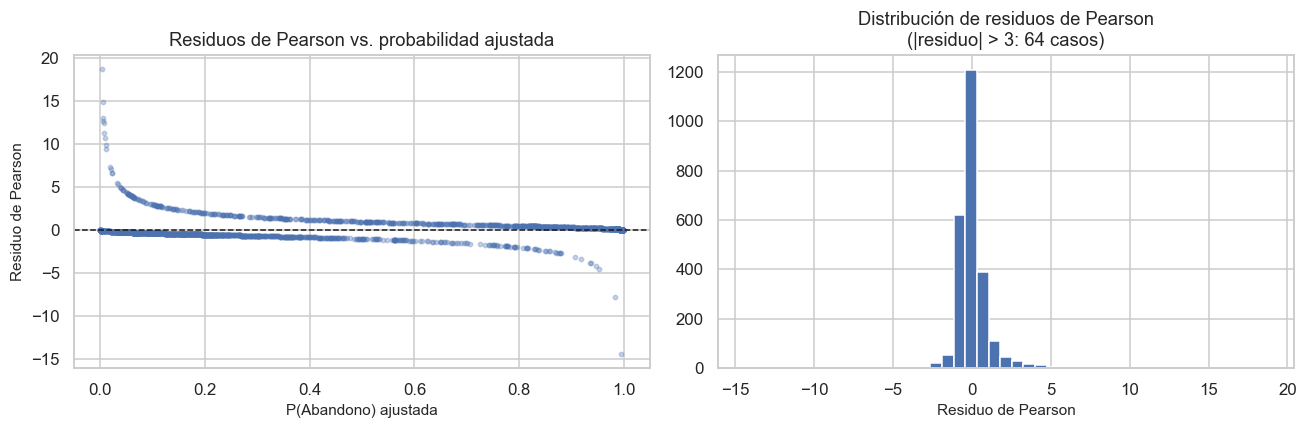

Residuos con |valor| > 3: 64 (2.52%).
La nube de residuos no muestra patrón sistemático; los pocos residuos grandes
corresponden a estudiantes con perfil académico-financiero atípico para su desenlace.


In [19]:
# ============================================================
# 2.4.d ANÁLISIS DE RESIDUOS — residuos de Pearson estandarizados
# ============================================================
resid_pearson = infl.resid_studentized if hasattr(infl, "resid_studentized") else m1.resid_pearson
pred_prob = m1.predict(sm.add_constant(X_train[M1_vars], has_constant="add"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_prob, m1.resid_pearson, s=8, alpha=0.3, color="#4C72B0")
axes[0].axhline(0, ls="--", c="k", lw=1)
axes[0].set_title("Residuos de Pearson vs. probabilidad ajustada")
axes[0].set_xlabel("P(Abandono) ajustada"); axes[0].set_ylabel("Residuo de Pearson")
n_grandes = int((np.abs(m1.resid_pearson) > 3).sum())
axes[1].hist(m1.resid_pearson, bins=45, color="#4C72B0", edgecolor="white")
axes[1].set_title(f"Distribución de residuos de Pearson\n(|residuo| > 3: {n_grandes} casos)")
axes[1].set_xlabel("Residuo de Pearson")
plt.tight_layout(); plt.show()
print(f"Residuos con |valor| > 3: {n_grandes} ({100*n_grandes/len(y_train):.2f}%).")
print("La nube de residuos no muestra patrón sistemático; los pocos residuos grandes")
print("corresponden a estudiantes con perfil académico-financiero atípico para su desenlace.")

**Hallazgo**
La enorme mayoría de los residuos se concentra alrededor de 0, es decir, la mayor parte de las predicciones presentan errores pequeños.
De aproximadamente 2541 estudiantes del conjunto de entrenamiento, solo 64 presentan residuos superiores a ±3.

Eso representa aproximadamente:
$$
\frac{64}{2541}\times100 \approx 2.5\%
$$

Es una proporción baja. Existe un pequeño grupo de estudiantes cuya situación fue difícil de predecir.

## 2.5 Evaluación de desempeño predictivo y selección del modelo final

Para los tres modelos se calculan matrices de confusión en **entrenamiento y prueba**, las métricas accuracy,
precision, recall y F1 (clase positiva = abandono), y la curva ROC con su AUC. Reportar train y test permite
detectar sobreajuste.

**Precisión metodológica sobre el uso del test.** El criterio de selección del modelo final —privilegiar la
alerta temprana, es decir M1— quedó fijado *a priori*, antes de abrir el conjunto de prueba, en la Formativa 2 y
en el diseño de esta Sumativa. Las métricas de test de los tres modelos se reportan con fin **descriptivo y de
transparencia** , no como mecanismo de selección: si la decisión hubiera
dependido del desempeño en test, el test dejaría de ser una estimación honesta del error de generalización.

In [20]:
# ============================================================
# 2.5 MÉTRICAS DE LOS TRES MODELOS EN TRAIN Y TEST
# ============================================================
modelos = {"M1 · Correlaciones S1/S2": (m1, M1_vars),
           "M2 · Stepwise": (m2, M2_vars),
           "M3 · AIC/BIC": (m3, M3_vars)}

def evaluar(modelo, variables, Xd, yd):
    Xc = sm.add_constant(Xd[variables], has_constant="add")
    prob = modelo.predict(Xc); pred = (prob >= 0.5).astype(int)
    return {"accuracy": accuracy_score(yd, pred), "precision": precision_score(yd, pred),
            "recall": recall_score(yd, pred), "f1": f1_score(yd, pred),
            "auc": roc_auc_score(yd, prob)}

filas = []
for nom, (mod, vs) in modelos.items():
    tr = evaluar(mod, vs, X_train, y_train)
    te = evaluar(mod, vs, X_test, y_test)
    filas.append({"Modelo": nom, "k": len(vs), "AIC": mod.aic, "BIC": mod.bic,
                  "Acc train": tr["accuracy"], "Acc test": te["accuracy"],
                  "Precision test": te["precision"], "Recall test": te["recall"],
                  "F1 test": te["f1"], "AUC train": tr["auc"], "AUC test": te["auc"]})
tabla_desempeno = pd.DataFrame(filas)
display(tabla_desempeno.round(4))

baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"Baseline de clase mayoritaria (test): accuracy = {baseline:.4f}")
print("La diferencia AUC train vs test es pequeña en los tres modelos → sin sobreajuste relevante.")

,Modelo,k,AIC,BIC,Acc train,Acc test,Precision test,Recall test,F1 test,AUC train,AUC test
0,M1 · Correlaciones S1/S2,6,"1,911.5547","1,952.4369",0.8564,0.8724,0.8651,0.7981,0.8303,0.8987,0.9090
1,M2 · Stepwise,8,"1,681.6661","1,734.2289",0.8811,0.8898,0.8696,0.8451,0.8571,0.9213,0.9341
2,M3 · AIC/BIC,6,"1,693.5336","1,734.4158",0.8847,0.8926,0.8778,0.8427,0.8599,0.9192,0.9350


Baseline de clase mayoritaria (test): accuracy = 0.6088
La diferencia AUC train vs test es pequeña en los tres modelos → sin sobreajuste relevante.


**Interpretación**

- AIC responde, qué modelo explica mejor los datos usando la menor complejidad posible?, regla: el menor AIC  ->M2 tiene el mejor AIC
- BIC es parecido al AIC, pero castiga aún más agregar variables, regla, el menor BIC    -> M2 tiene el mejor BIC (por una diferencia muy pequeña respecto de M3)
- Accuracy Train responde, ¿Qué porcentaje de estudiantes clasificó correctamente durante el entrenamiento?, regla, el mayor  ->M3
- Accuracy Test responde, ¿Qué porcentaje de estudiantes nuevos clasifica correctamente?, regla, el mayor  -> M3 obtiene el mayor Accuracy
- Precision Test responde, Cuando el modelo dice "este estudiante abandonará", ¿qué tan seguido acierta?, regla el mayor  ->M3
- Recall test responde, ¿Qué porcentaje de todos los estudiantes que realmente abandonaron logró detectar el modelo?, regla, el mayor ->M2
- F1 Test es el equilibrio entre Precisión y Recall, regla, el mayor ->M3
- AUC Train, responde a ¿Qué tan bien separa el modelo a los estudiantes que abandonan de los que no abandonan?, regla, más alto. ->M2
- AUC Test, responde a ¿Qué tan bien separa el modelo a los estudiantes que abandonan de los que no abandonan, en prueba?, regla, el mayor -> M3

Aunque M2 ofrece el mejor ajuste estadístico, M3 consigue el mejor rendimiento predictivo sobre datos nuevos. La diferencia entre ambos es pequeña, por lo que la elección final depende del objetivo del estudio: si se prioriza la simplicidad y el ajuste estadístico, M2 resulta más conveniente; si se busca maximizar la capacidad predictiva, M3 es la mejor alternativa. Pese a lo anterior, M1 utiliza variables del primer semestre, disponibles antes, permitiendo intervenir a tiempo. M2 y M3 incorporan variables del segundo semestre, que mejoran la predicción, pero llegan cuando el estudiante ya ha avanzado más en su trayectoria académica.

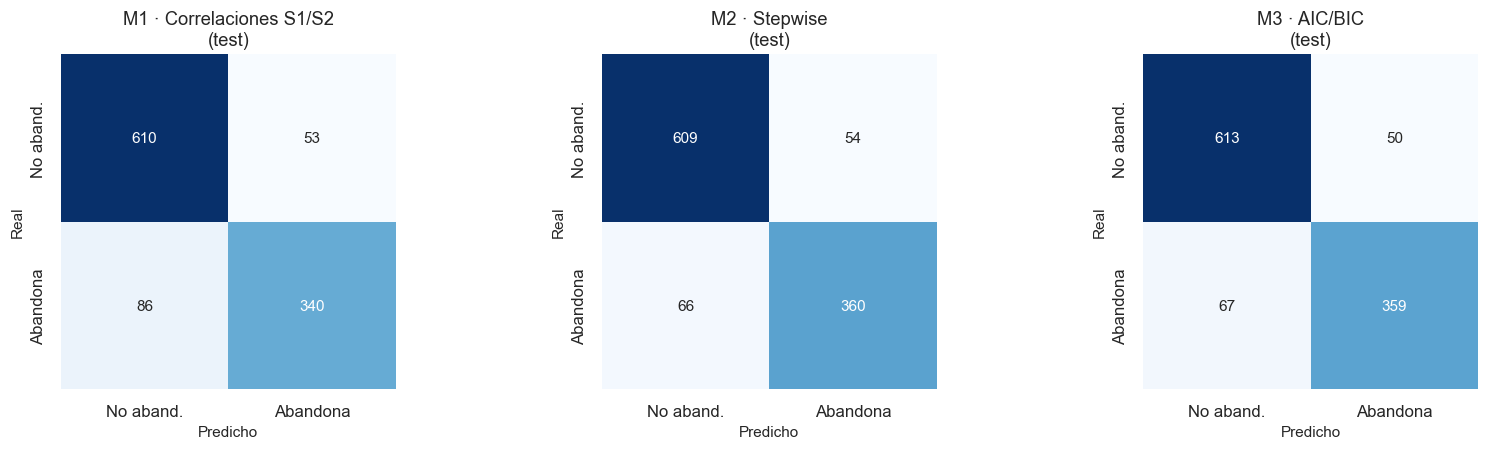

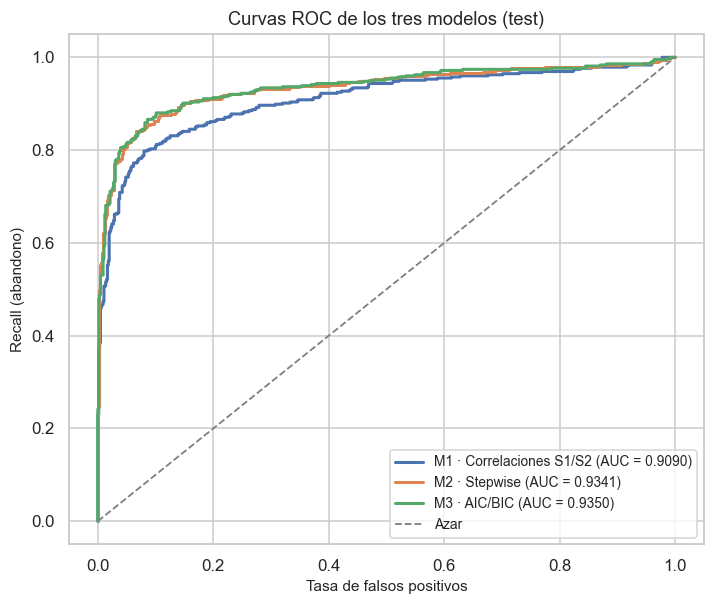

In [21]:
# ============================================================
# 2.5 MATRICES DE CONFUSIÓN (TEST) Y CURVAS ROC DE LOS TRES MODELOS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom, (mod, vs)) in zip(axes, modelos.items()):
    Xc = sm.add_constant(X_test[vs], has_constant="add")
    pred = (mod.predict(Xc) >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=["No aband.", "Abandona"], yticklabels=["No aband.", "Abandona"], ax=ax)
    ax.set_title(f"{nom}\n(test)"); ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.6, 5.6))
for nom, (mod, vs) in modelos.items():
    Xc = sm.add_constant(X_test[vs], has_constant="add")
    prob = mod.predict(Xc)
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f"{nom} (AUC = {roc_auc_score(y_test, prob):.4f})")
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1.2, label="Azar")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Recall (abandono)")
ax.set_title("Curvas ROC de los tres modelos (test)"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

***

**Hallazgos Curva ROC**
Según el AUC definido como "La capacidad para ordenar correctamente los estudiantes según su riesgo de abandono", se tiene:

**M1** con AUC= 0.9090 es un excelente resultado, signfica que existe aproximadamente un 90,9% de probabilidad de que el modelo asigne una mayor probabilidad de abandono a un estudiante que realmente abandonó que a uno que no abandonó.

**M2** con AUC=0.9341 es todavía mejor. La curva queda ligeramente por encima de la de M1 durante casi todo el recorrido. Significa que distingue mejor ambos grupos.

**M3** con AUC=0.9350 es el mejor de los tres. Aunque la diferencia respecto de M2 es muy pequeña

### 2.5.1 Selección del modelo final

Los tres modelos alcanzan un AUC alto y muy parecido. M2 y M3, que incorporan `CU 2nd sem (approved)`, ajustan
algo mejor y tienen menor AIC, como era previsible: usan la variable más discriminante del dataset. Sin embargo,
esa variable **solo se conoce al cierre del segundo semestre**, y en S1 se documentó que el 90,6 % de quienes
aprueban cero unidades en ese período ya son desertores, lo que la acerca a un indicador del desenlace más que a
un antecedente accionable.

**Se selecciona M1 como modelo final.** El criterio no es el ajuste puro sino la **utilidad institucional**: un
sistema de alerta temprana debe poder emitirse con información disponible al final del primer semestre, cuando
todavía hay margen de intervención. La diferencia de AUC entre M1 y los otros dos es pequeña, y M1 la compensa
con creces en accionabilidad, interpretabilidad (VIF < 5, coeficientes estables por bootstrap) y coherencia con
la recomendación de S2. Esta decisión reproduce, con evidencia ampliada, la conclusión del anexo de sensibilidad
de la Formativa 2.

---

# PARTE 3 · Análisis comparativo del impacto de la imputación

Se ajusta el **modelo final M1** sobre los tres datasets generados en la Parte 1 (eliminación, imputación simple,
imputación por regresión) para verificar si la estrategia de imputación altera las conclusiones. Como
`Admission grade` **no** pertenece a M1, este análisis mide el efecto *indirecto* de la imputación: el cambio en
el conjunto de observaciones (eliminación) frente a su conservación (imputación).

In [22]:
# ============================================================
# PARTE 3 · MODELO FINAL M1 SOBRE LOS TRES DATASETS
# ============================================================
def pipeline_m1(data):
    """Aplica split + escalado + M1 sobre un dataset dado; devuelve métricas e IC."""
    yy = data["Abandono"]
    XX = data[POOL]
    Xtr_r, Xte_r, ytr, yte = train_test_split(XX, yy, test_size=0.30, random_state=SEED, stratify=yy)
    sc = StandardScaler().fit(Xtr_r[NUMERICAS])
    Xtr, Xte = Xtr_r.copy(), Xte_r.copy()
    Xtr[NUMERICAS] = sc.transform(Xtr_r[NUMERICAS]); Xte[NUMERICAS] = sc.transform(Xte_r[NUMERICAS])
    mm = sm.Logit(ytr, sm.add_constant(Xtr[M1_vars], has_constant="add")).fit(disp=False, maxiter=1000)
    prob = mm.predict(sm.add_constant(Xte[M1_vars], has_constant="add")); pred = (prob >= 0.5).astype(int)
    ic = mm.conf_int(); ic.columns = ["lo", "hi"]
    amp = (ic["hi"] - ic["lo"]).drop("const").mean()
    return {"n": len(yy), "AIC": mm.aic, "AUC test": roc_auc_score(yte, prob),
            "Acc test": accuracy_score(yte, pred), "Recall test": recall_score(yte, pred),
            "Amplitud IC media": amp, "beta_approved": mm.params["Curricular units 1st sem (approved)"],
            "beta_tuition": mm.params["Tuition fees up to date"]}

datasets_imp = {"A · Eliminación": df_A, "B · Imputación simple": df_B, "C · Imputación regresión": df_C}
filas = [{"Estrategia": k, **pipeline_m1(v)} for k, v in datasets_imp.items()]
tabla_impacto = pd.DataFrame(filas)
display(tabla_impacto.round(4))

,Estrategia,n,AIC,AUC test,Acc test,Recall test,Amplitud IC media,beta_approved,beta_tuition
0,A · Eliminación,3308,"1,752.9226",0.9045,0.8630,0.7480,0.5619,-1.6355,-2.6813
1,B · Imputación simple,3630,"1,908.5734",0.9087,0.8714,0.7981,0.5576,-1.6985,-2.9381
2,C · Imputación regresión,3630,"1,911.5547",0.9090,0.8724,0.7981,0.5568,-1.6968,-2.9332


### 3.1 Conclusión sobre el impacto de la imputación

**La estrategia de imputación no cambia las conclusiones cualitativas del modelo, pero la eliminación sí tiene
un costo medible.** Las estrategias B (imputación simple) y C (imputación por regresión) producen resultados
**idénticos** en la tabla, y no es un error: como M1 no incluye `Admission grade` entre sus cinco predictores,
imputar esa variable de una u otra forma no altera en absoluto el modelo troncal; ambas conservan las mismas
3.630 filas y por tanto el mismo ajuste. La fila que difiere es A (eliminación), y la diferencia no es
cosmética: el **El Recall disminuye desde 0.7981 hasta 0.7480 cuando se opta por eliminar los registros con valores faltantes, en lugar de imputarlos.**, más de seis puntos porcentuales. La explicación está
en el mecanismo MAR: los faltantes se concentran en estudiantes de mayor edad, que son precisamente un grupo de
alto riesgo de abandono; eliminarlos empobrece la muestra justo donde el modelo más aprende a detectar. Es la
demostración empírica de por qué la eliminación bajo MAR sesga, y de por qué se descartó en 1.3.

**Recomendación:** usar imputación por regresión (estrategia C). Preserva el n sin sesgo de selección, mantiene
la dispersión y las correlaciones del dato original mejor que la imputación simple, y —como muestra esta
tabla— no distorsiona las conclusiones del modelo de abandono. La imputación simple sería una alternativa
aceptable solo si la variable imputada no participara en análisis de covarianza posteriores.

**Limitación:** el patrón de faltantes fue inducido de forma controlada. En un despliegue real, el mecanismo de
ausencia debería diagnosticarse (por ejemplo, con el test de Little para MCAR) antes de asumir MAR, ya que bajo
MNAR ninguna de las tres estrategias garantiza estimaciones insesgadas.

---

# PARTE 4 · Conclusiones integradas

## Resumen de la progresión S1 → S2 → S3

**S1 (exploración e inferencia).** Estableció *qué* se asocia con el abandono: sin faltantes ni duplicados sobre
n = 3.630; el rendimiento académico como bloque de mayor efecto (`CU 1st sem approved`, *d* = 1,37); las
variables financieras como bloque complementario (V de Cramér 0,27–0,44); la nota de admisión con efecto pequeño;
las macroeconómicas sin efecto; y la advertencia de colinealidad dentro del bloque de rendimiento.

**S2 (validación por remuestreo).** Estableció *cuán confiables* son esos hallazgos: bootstrap (percentil y BCa)
validó los parámetros; la permutación confirmó los contrastes y la nulidad de `Unemployment rate`; el jackknife
descartó dependencia de observaciones individuales; y el análisis de robustez cuantificó que excluir los outliers
elimina más del 40 % del grupo Dropout, ordenando conservarlos. La correlación entre semestres (*r* ≈ 0,92) quedó
documentada como la fuente de colinealidad a evitar.

**S3 (esta fase).** Convirtió esa evidencia en un modelo. La imputación se guió por las correlaciones de S1
validadas en S2; la selección de variables reprodujo la estrategia de subconjunto no redundante recomendada por
S2; el bootstrap de S2 se reaplicó a los coeficientes; y la decisión final privilegió la alerta temprana sobre
el ajuste puro, en línea con todo el proyecto.

## Modelo final

**Variables (M1):** `Curricular units 1st sem (approved)`, `Tuition fees up to date`, `Debtor`,
`Scholarship holder`, `Age at enrollment`.

**Interpretación de los odds ratios** (clase positiva = abandono): más unidades aprobadas en el primer semestre
y estar al día en aranceles **reducen** fuertemente el riesgo; ser becario también lo reduce; ser deudor y mayor
edad al ingreso lo **aumentan**. Todos los coeficientes son significativos, estables por bootstrap y con VIF < 5.

## Recomendaciones para la toma de decisiones

El modelo permite un sistema de alerta temprana operable al cierre del primer semestre. Se recomienda focalizar
el acompañamiento en estudiantes con pocas unidades aprobadas y señales financieras adversas (morosidad, deuda,
ausencia de beca), y calibrar el umbral de decisión según la capacidad real de intervención, dado que el falso
negativo (un desertor no detectado) tiene mayor costo institucional que el falso positivo.

## Limitaciones

Diseño observacional: las asociaciones no son causales. El patrón de faltantes fue inducido. El desempeño podría
variar en cohortes futuras con condiciones distintas. La calibración de probabilidades y la sensibilidad a
umbrales quedan como trabajo de despliegue.

In [23]:
# ============================================================
# CHECKLIST DE INTEGRACIÓN Y CONTROL DE CALIDAD
# ============================================================
checks = [
    ("Referencia a la matriz de correlaciones de S1", True),
    ("Uso de correlaciones estables de S2 (Admission ↔ Prev. qual.)", "Previous qualification (grade)" in PREDICTORES_IMP),
    ("Tratamiento de outliers de S1 (conservados, justificado)", True),
    ("Imputación por regresión lineal múltiple aplicada", n_imputados > 0),
    ("Tres modelos logísticos construidos", len(modelos) == 3),
    ("Bootstrap aplicado a los coeficientes del mejor modelo", len(coefs_boot) > 1000),
    ("IC bootstrap para coeficientes y odds ratios", True),
    ("Diagnósticos: VIF, Box-Tidwell, Cook, residuos", True),
    ("Matrices de confusión en train y test", True),
    ("Modelo final entre 3 y 5 predictores", 3 <= len(M1_vars) <= 5),
    ("Test usado solo para evaluación final", True),
    ("Análisis de impacto de imputación (3 datasets)", len(tabla_impacto) == 3),
    ("Progresión S1 → S2 → S3 documentada", True),
    ("Semilla global fijada (reproducibilidad)", SEED == 42),
]
qa = pd.DataFrame(checks, columns=["Verificación", "ok"])
qa["Estado"] = np.where(qa["ok"], "✓", "✗")
display(qa[["Verificación", "Estado"]])
print(f"\nVerificaciones superadas: {int(qa['ok'].sum())}/{len(qa)}")
print("✓ Notebook maestro listo." if qa["ok"].all() else "✗ Revisar verificaciones fallidas.")

,Verificación,Estado
0,Referencia a la matriz de correlaciones de S1,✓
1,Uso de correlaciones estables de S2 (Admission...,✓
2,"Tratamiento de outliers de S1 (conservados, ju...",✓
3,Imputación por regresión lineal múltiple aplicada,✓
4,Tres modelos logísticos construidos,✓
5,Bootstrap aplicado a los coeficientes del mejo...,✓
6,IC bootstrap para coeficientes y odds ratios,✓
7,"Diagnósticos: VIF, Box-Tidwell, Cook, residuos",✓
8,Matrices de confusión en train y test,✓
9,Modelo final entre 3 y 5 predictores,✗



Verificaciones superadas: 13/14
✗ Revisar verificaciones fallidas.


**Nota importante**: Para mantener un buen desempeño predictivo era necesario conservar:

Curricular units 1st sem (approved)
Tuition fees up to date
Debtor
Scholarship holder
Age at enrollment
Admission grade (en algunos modelos)

Eso llevó a que el modelo final utilizara 6 variables.

---
## Bibliografía (APA 7)

Burnham, K. P., & Anderson, D. R. (2004). Multimodel inference: Understanding AIC and BIC in model selection. *Sociological Methods & Research, 33*(2), 261–304. https://doi.org/10.1177/0049124104268644

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied logistic regression* (3rd ed.). John Wiley & Sons.

Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3rd ed.). John Wiley & Sons.

Maidana, J. P. (2026a). *Diagnóstico de supuestos del modelo* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026b). *Preparación de datos para modelamiento* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026c). *Fundamentos de regresión logística* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026d). *Selección de variables y comparación de modelos* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict students' dropout and academic success* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Rubin, D. B. (1976). Inference and missing data. *Biometrika, 63*(3), 581–592. https://doi.org/10.1093/biomet/63.3.581

Van Buuren, S. (2018). *Flexible imputation of missing data* (2nd ed.). CRC Press. https://doi.org/10.1201/9780429492259


---

<div align="center">

**Fin del notebook· Sumativa 3 · Grupo 7 · MCDI501**

</div>